## Computing the probability distribution of ring parameters from observed stellar density
### By Jorge I. Zuluaga, Pablo Agudelo, David Kipping

### Formulation of the problem

Using transity photometry of an exoplanet we have obtained the posterior probability distribution function (pdf) of the observed stellar density ($\rho_\mathrm{obs}$) of the host star. We also have estimations of the stellar mass $M_\star$ and radius $R_\star$ (mean values and errors), and therefore of the stellar true density $\rho_\mathrm{true}$ (a pdf).

Our goal is to determine the probability distribution function (pdf) of the planet and ring properties (size and orientation) that better explain the observed stellar density, provided the true stellar density.

### Available information

Information we assume it is known without any uncertainty:

- Planetary orbit eccentricity, $e_\mathrm{orb}$
- Planetart orbit inclination, $i_\mathrm{orb}$ or impact parameter $b$.
- Transit depth, $p$.
- Planet mass, $M_p$.

Information that are part of the transit photometry fitting procedure

- Planet orbit semimajor axis, $a_\mathrm{orb}$, which is normally expressed as a ratio $a_\mathrm{orb}/R_\star$
- Planet orbital period, $P_\mathrm{orb} = P_\mathrm{orb}(a,M_\star)$
- Ringless planet radius, $R_p^0 = (pR_\star^2)^{1/2}$.

Information that we know with errors or pdf:

- Posterior distribution of the observed stellar density, $p(\rho_\mathrm{obs})$.

- Stellar mass $M_\star$ and radius $R_\star$ are assumed to follow a simple (truncated) multivariate normal distribution function, $g(M_\star,R_\star) = N_{T}(\{\bar M_\star,\bar R_\star\};\Sigma)$.

- We assume that we know the mean observed value $\bar M_\star$ and $\bar R_\star$ and have an estimation of the standard deviadtion $\sigma_M$ and $\sigma_R$.

- For more complicated cases, for instance, when we have the pdf of the true stellar density $f(\rho_\star)$, we may play with the (unknown) correlation factor $\rho_{MR}$ to reconstruct $f(\rho_\star)$ from $g(M_\star,R_\star)$.

Information we want to determine:

- Planetary radius for a ringed planet, $R_p$. Units: meters. Potential range: [$R_p^\mathrm{min} = R_\oplus (M_p/M_\oplus)^{1/3}$, $R_p^\mathrm{max} = R_p^0$].
- Radius of the external ring, $f_e$ in units of $R_p$. $f_e=1$ means there are not rings. Units: adimensional. Potential range: [1,5].
- Inclination of the ring with respect to the orbit plane, $i_\mathrm{r}$. $i_\mathrm{r}=0$ means the rings are in the plane of the orbit. Units: degrees. Potential range: [0,90].
- Roll rotation of the ring, $\phi_\mathrm{r}$. $\phi_\mathrm{r}=0$ means that the node line of the ring are over the plane of the sky. Units: degrees. Potential range: [0,90].
- Normal optical depth of the ring, $\tau$. $\tau=0$ means the rings are transparent. Units: adimensional. Potential range: [0,5].

### Probability assumptions

Given a set of ringed-planet properties we can estimate the observed density:

$$
\rho_\mathrm{obs}(R_p,f_e,i_r,\phi_r;R_\star,M_\star)
$$

For simplicity we will assume that the probability of the planet parameters $q(R_p,f_e,i_r,\phi_r;R_\star,M_\star)$ is proportional to the observed stellar density, namely:

$$
q(R_p,f_e,i_r,\phi_r;R_\star,M_\star) \propto p(\rho_{obs}(R_p,f_e,i_r,\phi_r;R_\star,M_\star))
$$

**NOTE**: This is not strictly true. In fact, according to the coarea formula ([Wikipedia](https://en.wikipedia.org/wiki/Coarea_formula); [Negro, 2021](https://arxiv.org/pdf/2110.01441)) the relationship between both probability distributions will be:
$$
q(\mathbf{x})=\frac{p(\rho_\mathrm{obs}(\mathbf{x}))}{I(\rho_\mathrm{obs}(\mathbf{x}))}
$$
where he coarea factor is:
$$
I(\rho_\mathrm{obs}(\mathbf{x})) = \int_{L_{\rho_\mathrm{obs}(\mathbf{x})}} \frac{d S_{\mathbf{z}}}{\|\nabla \rho_\mathrm{obs}(\mathbf{z})\|}
$$
and $L_{\rho} = \{\mathbf{x} \in D \mid \rho_\mathrm{obs}(\mathbf{x})=\rho\}$ is a level set.

Estimating the coarea factor $I(\rho_\mathrm{obs}(\mathbf{x}))$ is not trivial due to the high dimensionality of the problem, we should remain that $\mathbf{x}:R_p,f_e,i_r,\phi_r,R_\star,M_\star$, and due to the fact that $\rho_\mathrm{obs}(\mathbf{x})$ is a numerical function that cannot be expressed in terms of elemental functions.  Although numerical procedures can be devised to estimate these factor, we have verified that it does not impact significantly generation of a random sample using the MCMC procedure. This is because in the Metropolis-Hasting algorithm, acceptance probability of a new sample $\mathbf{x}'$ will depend on the ratio:

$$
A\left(\mathbf{x} \rightarrow \mathbf{x}^{\prime}\right) = \frac{q(\mathbf{x'})}{q(\mathbf{x})} = \frac{p(\rho_\mathrm{obs}(\mathbf{x}'))}{p(\rho_\mathrm{obs}(\mathbf{x}))}
\frac{I(\rho_\mathrm{obs}(\mathbf{x}))}{I(\rho_\mathrm{obs}(\mathbf{x}'))}
$$

If we guarantee that the new sample $\mathbf{x}'$ is close to $\mathbf{x}$, and that the function $\rho_\mathrm{obs}(\mathbf{x})$ does not change significantly from one point to the other, then the ratio $I(\rho_\mathrm{obs}(\mathbf{x}))/I(\rho_\mathrm{obs}(\mathbf{x}'))$ is close to unit. We have performed numerical experiments to verify this.

### Method

For estimating $q(\cdots)$ we will generate using Markov Chain Monte Carlo (MCMC) a sample of the parameters $R_p,f_e,i_r,\phi_r,R_\star,M_\star$ and from their distribution we will get the desired posteriors.

Since we already know the distribution of $M_\star,R_\star$ our procedure will be divided in two steps.

1. Generate values of $R_\star$ and $M_\star$ than fulfills a given distribution.

2. Generate values of the planetary parameters set $\mathbf{p}:R_p,f_e,i_r,\phi_r$ according to the observed stellar density.

This is justified by the [law of total probability](https://en.wikipedia.org/wiki/Law_of_total_probability), that in our case give us the probability that a given planetary parameters set $\mathbf{p}$, irrespective the stellar properties:

$$
p(\mathbf{p}) = p(\mathbf{p}|R_\star^{(1)},M_\star^{(1)}) p(R_\star^{(1)},M_\star^{(1)}) + p(\mathbf{p}|R_\star^{(2)},M_\star^{(2)}) p(R_\star^{(2)},M_\star^{(2)}) + \cdots
$$
where $R_\star^{(i)},M_\star^{(i)}$ are discrete values of the stellar radius and mass.

### Algorithm

**Goal**: generate $N_s$ samples of the if the system parameters $R_p,f_e,i_r,\phi_r, R_\star,M_\star$.

1. Create a meshgrid of $M_\star$ and $R_\star$, $\mathrm{dim}(N_M\times N_R$), in the intervals $M_\star - 3\sigma_M, M_\star + 3\sigma_M$ and $R_\star - 3\sigma_R, R_\star + 3\sigma_R$. According to the resolution (number of rows and columns of the grid) we will have grid interspacings of $\Delta M_\star$ and $\Delta R_\star$.

2. Start with guess values of the planetary parameters: $R_p,f_e,i_r,\phi_r$.

3. Set the intervals of the planetary parameters:
   - [$R_p^\mathrm{min} = R_\oplus (M_p/M_\oplus)^{1/3}$, $R_p^\mathrm{max} = R_p^0$]
   - [$f_e^\mathrm{min} = 1$, $f_e^\mathrm{max} = 5$]
   - [$i_r^\mathrm{min} = 0$, $i_r^\mathrm{max} = 90$]
   - [$\phi_r^\mathrm{min} = 0$, $\phi_r^\mathrm{max} = 90$]

3. Set the value of the steps for the random walk of planetary parameter x. We can use the ansatz $\Delta x = \epsilon_x (x^\mathrm{max} - x^\mathrm{min})$, where $\epsilon_x$ is a free parameter that can be set wisely for each parameter. For instance: $\Delta R_p = 0.05 (R_p^\mathrm{max} - R_p^\mathrm{min})$, here $\epsilon_{Rp}=0.05$.

4. Create an empty sample list, $\mathbf{X}:[]$.

4. For each pair of values $M_\star$ and $R_\star$ in the grid:

   1. Calculate the number of samples for this point in the grid of $M_\star$ and $R_\star$: $N_p = N_s N_{T}(\{\bar M_\star,\bar R_\star\};\Sigma)\Delta M_\star \Delta R_\star$, where $N_T(\cdot,\cdot)$ is the truncated multivariate normal distribution.

   > **NOTE**: If $N_{T}(\{\bar M_\star,\bar R_\star\};\Sigma)$ is properly normalized in the grid, then when summing up the values of $N_p$ it will give $N_s$. Since the size of the grid is large enough (up to 3-sigma in width), using the non-truncated version will still work although the $N_p$ will not add-up to $N_s$

   2. Calculate the observed density for the latest value of the planetary and stellar parameters: $\rho_\mathrm{obs} = \rho_\mathrm{obs}(R_p,f_e,i_r,\phi_r;R_\star,M_\star)$ and the true density $\rho_\mathrm{true} = M_\star/(4/3\pi R_\star^3)$.

   3. Store the observed angles $i_\mathrm{eff}, \theta_\mathrm{eff}$.

   4. Calculate the probability of the observed density: $p = p(\rho_{obs})$

   5. For $i$ in $N_p$:

      1. Modify each planetary parameter using: $x' = x + \delta x$, where $\delta x \sim N(0,\Delta x)$ (generate a random gaussian number with mean 0 and standard deviation $\Delta x$).

      2. Calculate the observed density of the new set of planetary parameters: $\rho_\mathrm{obs}' = \rho_\mathrm{obs}(R_p',f_e',i_r',\phi_r';R_\star,M_\star)$.

      3. Store the observed angles $i_\mathrm{eff}', \theta_\mathrm{eff}'$.

      4. Calculate the probability of the new observed density $p' = p(\rho_{obs}')$

      5. Caclulate the acceptance ratio: $\alpha = \mathrm{min}(1,p'/p)$

      6. Generate a random number $u\sim \mathrm{Uniform}(0,1)$.

      7. If $u < \alpha$:
          
         1. Set the new accepted set of planetary parameters: $R_p,f_e,i_r,\phi_r, i_\mathrm{eff}, \theta_\mathrm{eff}= R_p',f_e',i_r',\phi_r',i_\mathrm{eff}', \theta_\mathrm{eff}'$.
          
         2. Set the observed stellar density: $\rho_\mathrm{obs} = \rho_\mathrm{obs}'$.

      7. Store the latest accepted set of planetary and stellar parameters: $\mathbf{X}.\mathrm{append}(R_p,f_e,i_r,\phi_r,i_\mathrm{eff}, \theta_\mathrm{eff},M_\star,R_\star,\rho_\mathrm{obs},\rho_\mathrm{true})$


### Observations

- As you may verify, if you take from the sample list, the number of times that a pair $M_\star, R_\star$ appears in the sample, they will follow the initial distribution of stellar mass and radius as desired.

- It could be interesting to store the sample in a matrix of samples $Q[\cdot,\cdot]$ in such a way that we can analyse how the planetary properties are distributed fixing a given stellar mass and radius. Thus for instance the $Q[0,0]$ sample will be the list of planetary parameters corresponding to the stellar mass and radius in the (0,0) position of the meshgrid.

## Implementation

Propeties of the system are available at: https://exoplanetarchive.ipac.caltech.edu/overview/Kepler-51


In [1]:
import os
# Check if running in Google Colab
if 'COLAB_GPU' in os.environ:
    # Clone the repository
    !git clone -b refactor https://github.com/seap-udea/GeoTrans

    # Install gdown if not already installed
    !pip install -Uq gdown

    # Download the file using gdown
    # https://drive.google.com/file/d/1ZWFfb7vBHe4RMdCO71z7XDg41fSo-dB9/view?usp=drive_link
    !gdown 1ZWFfb7vBHe4RMdCO71z7XDg41fSo-dB9

    # Unzip the downloaded file
    !unzip -oq Kepler-51-data.zip

In [2]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.append('GeoTrans')
from geotrans2 import *
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.interpolate import interp1d
import pickle
from scipy.stats import norm
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")

### Extract system properties

In [3]:
df = pd.read_csv('Kepler-51/GKTHCatalog_Table4.csv')
k51 = df[df['id_starname'] == 'kic11773022']
k51.iso_mass, k51.iso_mass_err1, k51.iso_mass_err2, k51.iso_rad, k51.iso_rad_err1, k51.iso_rad_err2

(1820    0.914664
 Name: iso_mass, dtype: float64,
 1820    0.041197
 Name: iso_mass_err1, dtype: float64,
 1820   -0.058405
 Name: iso_mass_err2, dtype: float64,
 1820    0.868832
 Name: iso_rad, dtype: float64,
 1820    0.031755
 Name: iso_rad_err1, dtype: float64,
 1820   -0.026073
 Name: iso_rad_err2, dtype: float64)

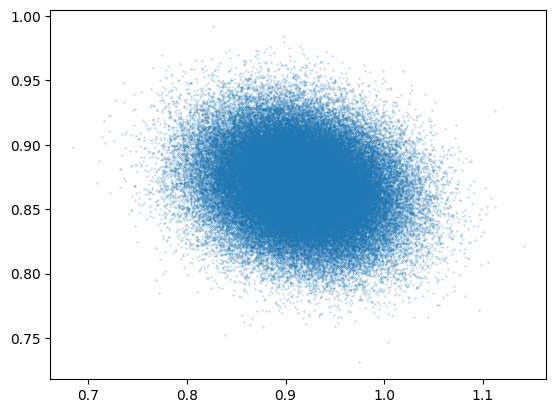

In [4]:
rho_true_sun = MSUN/(4/3 * np.pi * RSUN**3)

M_mean = k51.iso_mass.values[0]
R_mean = k51.iso_rad.values[0]
M_std = (k51.iso_mass_err1.values[0] + abs(k51.iso_mass_err2.values[0]))/2
R_std = (k51.iso_rad_err1.values[0] + abs(k51.iso_rad_err2.values[0]))/2

mean = [M_mean, R_mean]
rho_MR = -0.2
cov = [
    [M_std**2, rho_MR * M_std * R_std], 
    [rho_MR * M_std * R_std, R_std**2]
]

samples = np.random.multivariate_normal(mean, cov, int(1e5))

# Extract mass and radius samples
mass_samples = samples[:, 0]
radius_samples = samples[:, 1]

rho_samples = mass_samples / (radius_samples**3)*rho_true_sun

plt.scatter(mass_samples, radius_samples, s=0.1, alpha=0.5);

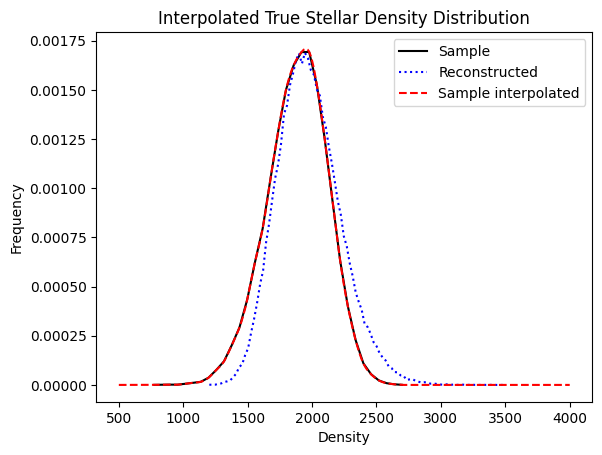

In [ ]:
rho_trues = np.loadtxt('Kepler-51/berger2023_rhostar.dat')

# Histogram rho_true
bins = int(len(rho_trues)/3000)
hs,rhos = np.histogram(rho_trues, bins=bins, density=True)
rhos = 0.5*(rhos[1:] + rhos[:-1])

# Plot
plt.plot(rhos, hs, 'k-',label='Sample')

# Interpolated function
rho_true_fun = interp1d(rhos, hs, kind='cubic', fill_value=(0,0), bounds_error=False)
# Pickle the functions
with open('rho_true_fun.pkl', 'wb') as f:
    pickle.dump(rho_true_fun, f)

# Histogram rho_samples
bins = int(len(rho_samples)/1000)
hs,rhos = np.histogram(rho_samples, bins=bins, density=True)
rhos = 0.5*(rhos[1:] + rhos[:-1])
rho_sample_fun = interp1d(rhos, hs, kind='cubic', fill_value=(0,0), bounds_error=False)
plt.plot(rhos, hs, 'b:',label='Reconstructed')

# Interpolated/Extrapolated values
x = np.linspace(500, 4000, 400)
y = rho_true_fun(x)
plt.plot(x, y, 'r--',label='Sample interpolated')

# Decoration
plt.legend()
plt.xlabel('Density')
plt.ylabel('Frequency')
plt.title('Interpolated True Stellar Density Distribution')
plt.show()

#### Planetary properties

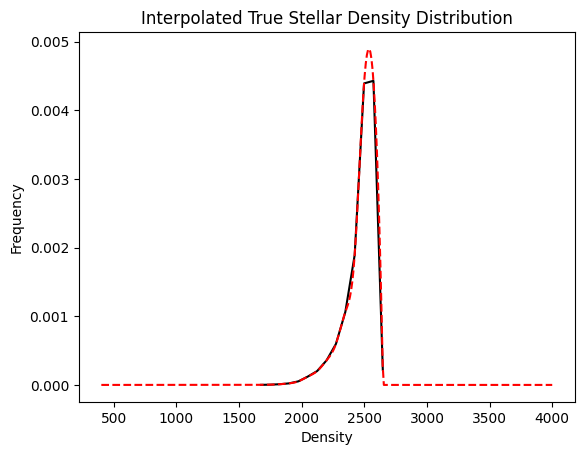

In [6]:
data = np.loadtxt('Kepler-51/Kepler-51b_45d/TTVplan3-post_equal_weights.dat')
rho_obs_b = data[:,1]

# Histogram
bins = int(len(rho_obs_b)/3000)
hs,rhos = np.histogram(rho_obs_b, bins=bins, density=True)
rhos = 0.5*(rhos[1:] + rhos[:-1])

# Interpolated function
rho_obs_fun = interp1d(rhos, hs, kind='cubic', fill_value=(0,0), bounds_error=False)

# Plot
plt.plot(rhos, hs, 'k-')

# Interpolated/Extrapolated values
x = np.linspace(400, 4000, 400)
y = rho_obs_fun(x)
plt.plot(x, y, 'r--')

# Decoration
plt.xlabel('Density')
plt.ylabel('Frequency')
plt.title('Interpolated True Stellar Density Distribution')
plt.show()

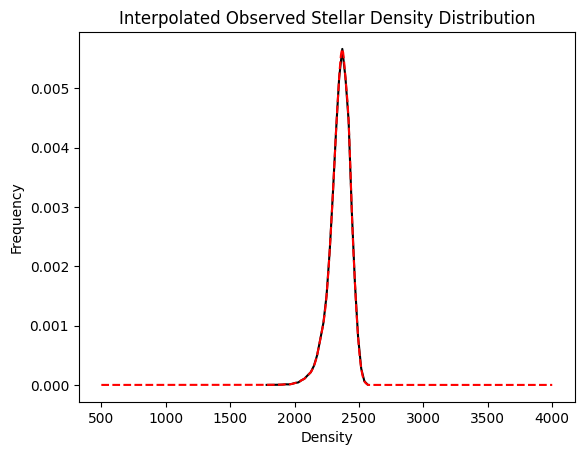

In [7]:
rho_obs_b = np.loadtxt('Kepler-51/Kepler-51b_45d/rhob_samples.dat')

# Histogram
bins = int(len(rho_obs_b)/3000)
hs,rhos = np.histogram(rho_obs_b, bins=bins, density=True)
rhos = 0.5*(rhos[1:] + rhos[:-1])

# Interpolated function
rho_obs_b_fun = interp1d(rhos, hs, kind='cubic', fill_value=(0,0), bounds_error=False)
with open('rho_obs_b_fun.pkl', 'wb') as f:
    pickle.dump(rho_obs_b_fun, f)

# Plot
plt.plot(rhos, hs, 'k-')

# Interpolated/Extrapolated values
x = np.linspace(500, 4000, 400)
y = rho_obs_b_fun(x)
plt.plot(x, y, 'r--')

# Decoration
plt.xlabel('Density')
plt.ylabel('Frequency')
plt.title('Interpolated Observed Stellar Density Distribution')
plt.show()

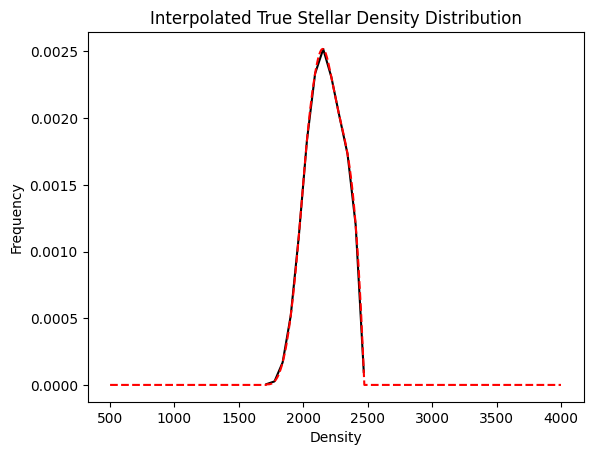

In [8]:
data = np.loadtxt('Kepler-51/Kepler-51c_130d/TTVplan-post_equal_weights.dat')
rho_obs_c = data[:,1]

# Histogram
bins = int(len(rho_obs_c)/3000)
hs,rhos = np.histogram(rho_obs_c, bins=bins, density=True)
rhos = 0.5*(rhos[1:] + rhos[:-1])

# Interpolated function
rho_obs_c_fun = interp1d(rhos, hs, kind='cubic', fill_value=(0,0), bounds_error=False)
with open('rho_obs_c_fun.pkl', 'wb') as f:
    pickle.dump(rho_obs_c_fun, f)

# Plot
plt.plot(rhos, hs, 'k-')

# Interpolated/Extrapolated values
x = np.linspace(500, 4000, 400)
y = rho_obs_c_fun(x)
plt.plot(x, y, 'r--')

# Decoration
plt.xlabel('Density')
plt.ylabel('Frequency')
plt.title('Interpolated True Stellar Density Distribution')
plt.show()

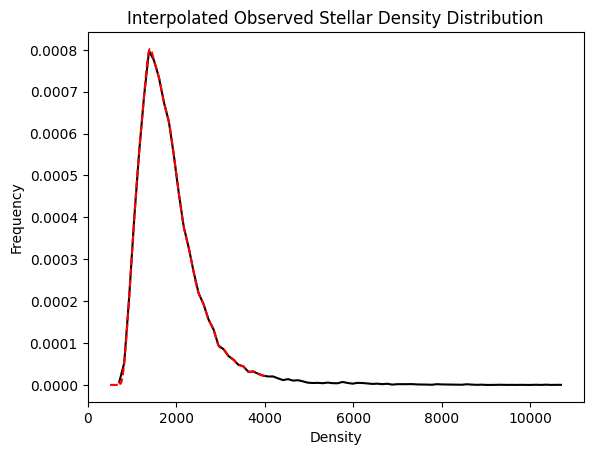

In [9]:
data = np.loadtxt('Kepler-51/Kepler-51d_85d/TTVplan-post_equal_weights.dat')
rho_obs_d = data[:,1]

# Histogram
bins = int(len(rho_obs_d)/500)
hs,rhos = np.histogram(rho_obs_d, bins=bins, density=True)
rhos = 0.5*(rhos[1:] + rhos[:-1])

# Interpolated function
rho_obs_d_fun = interp1d(rhos, hs, kind='cubic', fill_value=(0,0), bounds_error=False)
with open('rho_obs_d_fun.pkl', 'wb') as f:
    pickle.dump(rho_obs_d_fun, f)

# Plot
plt.plot(rhos, hs, 'k-')

# Interpolated/Extrapolated values
x = np.linspace(500, 4000, 400)
y = rho_obs_d_fun(x)
plt.plot(x, y, 'r--')

# Decoration
plt.xlabel('Density')
plt.ylabel('Frequency')
plt.title('Interpolated Observed Stellar Density Distribution')
plt.show()

### Load all densities

In [10]:
# Unpickle the functions
with open('rho_true_fun.pkl', 'rb') as f:
    rho_true_fun = pickle.load(f)

with open('rho_obs_b_fun.pkl', 'rb') as f:
    rho_obs_b_fun = pickle.load(f)

with open('rho_obs_c_fun.pkl', 'rb') as f:
    rho_obs_c_fun = pickle.load(f)

with open('rho_obs_d_fun.pkl', 'rb') as f:
    rho_obs_d_fun = pickle.load(f)

All densities

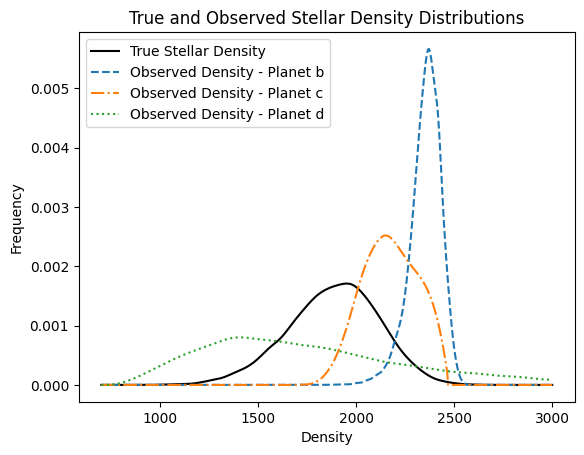

In [11]:
# Define the range for x-axis
x_range = np.linspace(700, 3000, 400)

# Plot rho_true_fun
plt.plot(x_range, rho_true_fun(x_range), label='True Stellar Density', color='black')

# Plot rho_obs_*_fun for each planet
plt.plot(x_range, rho_obs_b_fun(x_range), label='Observed Density - Planet b', linestyle='--')
plt.plot(x_range, rho_obs_c_fun(x_range), label='Observed Density - Planet c', linestyle='-.')
plt.plot(x_range, rho_obs_d_fun(x_range), label='Observed Density - Planet d', linestyle=':')

# Decoration
plt.xlabel('Density')
plt.ylabel('Frequency')
plt.title('True and Observed Stellar Density Distributions')
plt.legend()
plt.show()

### Tests before implementation

#### Planet d

Planetary data:

In [12]:
# Columns are: Rp/R*, rho* (km/m^3), b, P (ignore), tmid,0 (ignore), q1, q2
data = np.loadtxt('Kepler-51/Kepler-51b_45d/TTVplan3-post_equal_weights.dat')

(array([3.421e+03, 3.494e+03, 3.443e+03, 3.300e+03, 3.177e+03, 3.055e+03,
        2.797e+03, 2.643e+03, 2.469e+03, 2.188e+03, 1.942e+03, 1.818e+03,
        1.662e+03, 1.384e+03, 1.179e+03, 9.900e+02, 8.550e+02, 6.660e+02,
        5.700e+02, 4.500e+02, 3.260e+02, 2.500e+02, 1.920e+02, 1.070e+02,
        7.100e+01, 3.400e+01, 2.500e+01, 1.200e+01, 4.000e+00, 2.000e+00]),
 array([8.27835829e-06, 1.70463742e-02, 3.40844701e-02, 5.11225660e-02,
        6.81606619e-02, 8.51987578e-02, 1.02236854e-01, 1.19274950e-01,
        1.36313045e-01, 1.53351141e-01, 1.70389237e-01, 1.87427333e-01,
        2.04465429e-01, 2.21503525e-01, 2.38541621e-01, 2.55579717e-01,
        2.72617812e-01, 2.89655908e-01, 3.06694004e-01, 3.23732100e-01,
        3.40770196e-01, 3.57808292e-01, 3.74846388e-01, 3.91884484e-01,
        4.08922580e-01, 4.25960675e-01, 4.42998771e-01, 4.60036867e-01,
        4.77074963e-01, 4.94113059e-01, 5.11151155e-01]),
 <BarContainer object of 30 artists>)

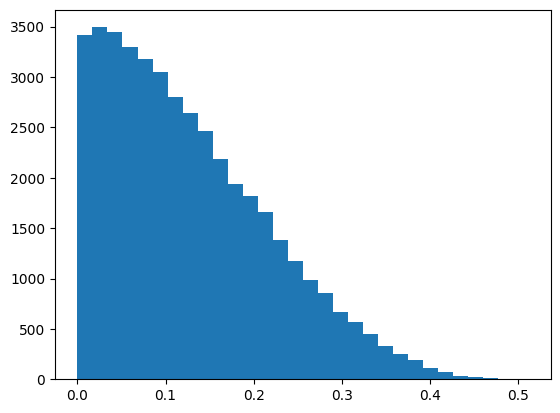

In [13]:
plt.hist(data[:,2], bins=30)

### Planet properties

In [14]:
# Planet d: Masuda et al. 2024

# ########################################################
# Observables level 0: astrophysically independent
# ########################################################
# ============================
# STELLAR PROPERTIES
# ============================
Ms_mean = M_mean*MSUN
Ms_std = M_std*MSUN
Rs_mean = R_mean*RSUN
Rs_std = R_std*RSUN

# ########################################################
# Observables level 1: theoretically independent
# ########################################################
# These are the observables that depends on few astrophysical parameters
# For instance: detemining the transit depth depends on few parameters

# ============================
# TRANSIT DEPTH
# ============================
# delta_mean = None; delta_std = None
qdelta = 0 # Make 1 if you have delta values

# If Rp and Rstar is known:
Rp_mean = 0.831*RJUP # Masuda et al. 2024
Rp_std = 0.016*RJUP # Masuda et al. 2024

delta_mean = (Rp_mean/Rs_mean)**2
delta_std = 2*delta_mean*(Rp_std/Rp_mean + Rs_std/Rs_mean)
print(f"Transit depth: {delta_mean*100:.2f} +/- {delta_std*100:.2f} %")
delta_fun = lambda x:norm.pdf(x, delta_mean, delta_std)

# ============================
# TRANSIT PERIOD
# ============================
# Orbital period
Porb_mean = 130.1858*DAY # Masuda et al. 2024
Porb_std = 0.0018*DAY # Masuda et al. 2024

# ########################################################
# Observables level 2: model dependent parameters
# ########################################################
# ============================
# IMPACT PARAMETER
# ============================
borb_mean = data[:,2].mean()
borb_sdt = data[:,2].std()

# ########################################################
# Observables level 2: dependent parameters
# ########################################################
# These are observables that can be calculated from previous parameters
# ============================
# PLANETARY RADIUS
# ============================
# These are the observables that depends on previous parameters
if qdelta:
    Rp_mean = delta_mean**0.5*Rs_mean
    Rp_std = 0.5*Rp_mean*(delta_std/delta_mean + 2*Rs_std/Rs_mean)

print(f"Planet radius: {Rp_mean/RJUP:.4f} +/- {Rp_std/RJUP:.4f} RJup")

# ============================
# SEMIMAJOR AXIS
# ============================
# Semimajor axis
ap_mean = ((GCONST * Ms_mean * Porb_mean**2) / (4 * pi**2))**(1/3)
ap_std = 1/3*ap_mean*(Ms_std/Ms_mean + 2*Porb_std/Porb_mean)
print(f"Semimajor axis: {ap_mean/AU:.4f} +/- {ap_std/AU:.4f} au")

# ============================
# ORBITAL INCLINATION
# ============================
iorb_mean = np.arccos(borb_mean*Rs_mean/ap_mean)*RAD
iorb_std = np.sqrt((borb_sdt * Rs_mean / ap_mean)**2 + \
                   (borb_mean * Rs_std / ap_mean)**2 + \
                   (borb_mean * Rs_mean * ap_std / ap_mean**2)**2) * RAD
print(f"Orbital inclination: {iorb_mean:.2f} +/- {iorb_std:.2f} degrees")

# ########################################################
# Observavles level 3: other parameters
# ########################################################
# Planetary mass
Mp_mean = 0.021*MJUP
Mp_std = 0.003*MJUP

# ============================
# MINIMUM PLANET RADIUS
# ============================
Rp_min = REARTH*(Mp_mean/MEARTH)**(1/3)
fRp_min = Rp_min/Rp_mean
print(f"Minimum planet radius: {Rp_min/RJUP:.4f} RJup")
print(f"Minimum planet radius in terms of the ringless planet radius: {fRp_min:.4f} Rp")

Sd = RingedSystem(
    system = dict(
        Mstar=Ms_mean,
        Rstar=Rs_mean,
        Rplanet=Rp_mean, # Libby-Roberts et al. 2020
        Mplanet=Mp_mean, # Libby-Roberts et al. 2020
        ap=ap_mean, #Semi-major axis # Libby-Roberts et al. 2020
        iorb=iorb_mean*DEG, #Orbital inclination
        fe=1, #Exterior ring (Rp)
        fi=1, #Interior ring (Rp)
        ir=0.0*DEG, #Ring inclination
        phir=0.0*DEG, #Ring roll angle
        tau=0.0, #Opacity
    )
)
Sd.noauto = True
Sd.calculate_PR()
print(f"rho_obs: {Sd.rho_obs}, rho_true: {Sd.rho_true}, PR: {Sd.PR}")

Transit depth: 0.92 +/- 0.10 %
Planet radius: 0.8310 +/- 0.0160 RJup
Semimajor axis: 0.4880 +/- 0.0089 au
Orbital inclination: 89.94 +/- 0.04 degrees
Minimum planet radius: 0.1716 RJup
Minimum planet radius in terms of the ringless planet radius: 0.2065 Rp
rho_obs: 1960.7133771390127, rho_true: 1960.8074257658545, PR: -2.0831101875362388e-05


Testing functionalities:

rho_obs: 1083.3289180965933, rho_true: 1960.8074257658545, PR: -0.2576746067183592
delta = 0.008681936495503194 compared to 0.009220971582152548


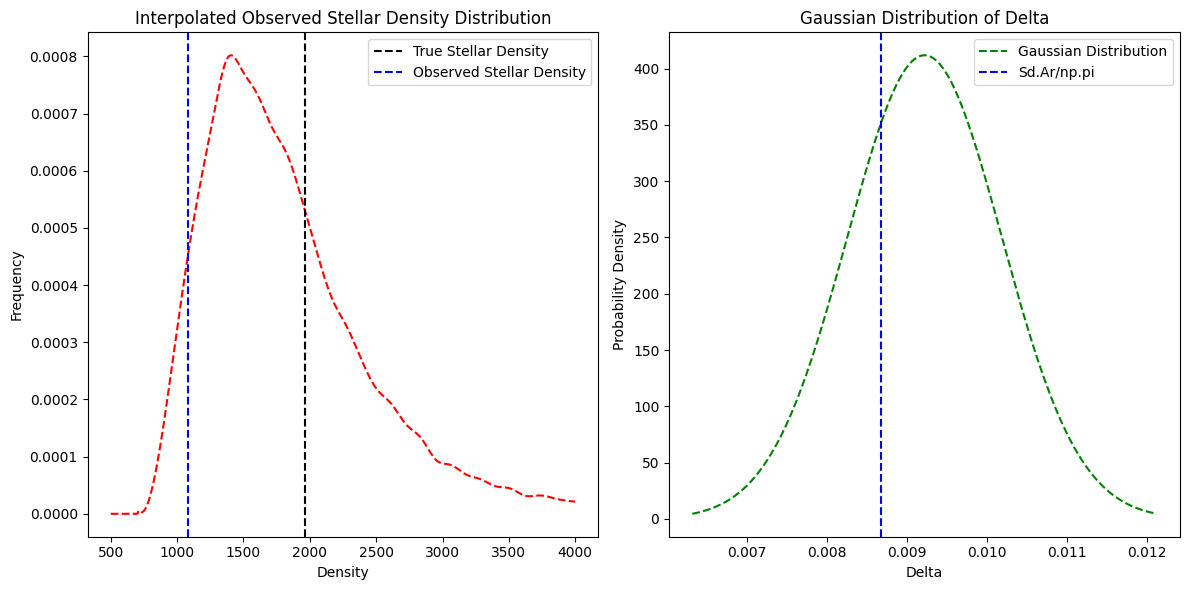

In [15]:
Sd.tau = 1.0
Sd.fe = 2.9
Sd.Rplanet = 0.5*Rp_mean
Sd.ir = 30*DEG 
Sd.phir = 0*DEG
Sd.updateSystem()
Sd.calculate_PR()
print(f"rho_obs: {Sd.rho_obs}, rho_true: {Sd.rho_true}, PR: {Sd.PR}")
print(f"delta = {Sd.Ar/np.pi} compared to {delta_mean}")

# Interpolated/Extrapolated values
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# First subplot
axs[0].plot(x, y, 'r--')
axs[0].axvline(Sd.rho_true, color='black', linestyle='--', label='True Stellar Density')
axs[0].axvline(Sd.rho_obs, color='blue', linestyle='--', label='Observed Stellar Density')
axs[0].set_xlabel('Density')
axs[0].set_ylabel('Frequency')
axs[0].set_title('Interpolated Observed Stellar Density Distribution')
axs[0].legend()

# Second subplot
delta_values = np.linspace(delta_mean - 3*delta_std, delta_mean + 3*delta_std, 400)
gaussian = (1/(delta_std * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((delta_values - delta_mean) / delta_std)**2)
axs[1].plot(delta_values, gaussian, 'g--', label='Gaussian Distribution')
axs[1].axvline(Sd.Ar/np.pi, color='blue', linestyle='--', label='Sd.Ar/np.pi')
axs[1].set_xlabel('Delta')
axs[1].set_ylabel('Probability Density')
axs[1].set_title('Gaussian Distribution of Delta')
axs[1].legend()

plt.tight_layout()
plt.show()

In [16]:
from ipywidgets import interact, FloatSlider

In [17]:
args = dict(continuous_update=False, readout_format='.2f')
@interact(
    fe = FloatSlider(value=2.5, min=1.1, max=3.0, step=0.1, **args),
    Rpf = FloatSlider(value=0.5, min=0.1, max=1.0, step=0.1, **args),
    ir = FloatSlider(value=45.0, min=0.0, max=90.0, step=1.0, **args)
)
def ring_fit(fe = 3.0, Rpf = 0.5, ir = 45):
    Sd.tau = 1.0
    Sd.fe = fe
    Sd.Rplanet = Rpf*Rp_mean
    Sd.ir = ir*DEG 
    Sd.phir = 0*DEG
    Sd.updateSystem()
    Sd.calculate_PR()
    print(f"rho_obs: {Sd.rho_obs}, rho_true: {Sd.rho_true}, PR: {Sd.PR}")
    print(f"delta = {Sd.Ar/np.pi} compared to {delta_mean}")

    # Interpolated/Extrapolated values
    fig, axs = plt.subplots(1, 2, figsize=(12, 6))

    # First subplot
    axs[0].plot(x, y, 'r--')
    axs[0].axvline(Sd.rho_true, color='black', linestyle='--', label='True Stellar Density')
    axs[0].axvline(Sd.rho_obs, color='blue', linestyle='-', label='Observed Stellar Density')
    axs[0].set_xlabel('Density')
    axs[0].set_ylabel('Frequency')
    axs[0].set_title('Interpolated Observed Stellar Density Distribution')
    axs[0].legend()

    # Second subplot
    delta_values = np.linspace(delta_mean - 3*delta_std, delta_mean + 3*delta_std, 400)
    gaussian = (1/(delta_std * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((delta_values - delta_mean) / delta_std)**2)
    axs[1].plot(delta_values, gaussian, 'g--', label='Gaussian Distribution')
    axs[1].axvline(Sd.Ar/np.pi, color='blue', linestyle='-', label='delta (predicted)')
    axs[1].set_xlabel('Delta')
    axs[1].set_ylabel('Probability Density')
    axs[1].set_title('Gaussian Distribution of Delta')
    axs[1].legend()

    plt.tight_layout()
    plt.show()

interactive(children=(FloatSlider(value=2.5, continuous_update=False, description='fe', max=3.0, min=1.1), Flo…

### MCMC implementation

In [18]:
# Parameters to vary: fe, fRp, ir

# Seed 
np.random.seed(10)
verbose = 1

# Fixed values
Sd.tau = 1.0
Sd.phir = 0*DEG

# Initial guess
fe = 2.5
fRp = 0.5
ir = 45.0

# Ranges
fe_range = 1.1, 4.0
fRp_range = fRp_min, 1.0
ir_range = 0.0,  90.0

# Step sizes
eps_fe = 0.05
eps_fRp = 0.05
eps_ir = 0.05

# Number of iterations
Np = int(1e4)

# Arrays to store the values:
# fe, fRp, ir, rho_true, rho_obs, PR, ieff, teff, M*, R*, delta
Xs = []

# Initial guess
Sd.fe = fe
Sd.Rplanet = fRp*Rp_mean
Sd.ir = ir*DEG
if verbose:print(f"Guess parameters: fe: {Sd.fe}, fRp: {Sd.Rplanet/Rp_mean}, ir: {Sd.ir*RAD}")

# Calculate probabilities
Sd.updateSystem()
Sd.calculate_PR()
rho_obs = Sd.rho_obs
rho_true = Sd.rho_true
delta = Sd.Ar/np.pi
PR = Sd.PR
ieff = Sd.ieff*RAD
teff = Sd.teff*RAD

p_rho_obs = float(rho_obs_d_fun(rho_obs))
p_delta = float(delta_fun(delta))

if verbose:print(f"\trho_obs: {rho_obs}, rho_true: {rho_true}, PR: {PR}, delta: {delta}")
if verbose:print(f"\tProbabilities: p_rho_obs: {p_rho_obs}, p_delta: {p_delta}")

for i in tqdm(range(Np)):

    if verbose:print(f"Step: {i}")

    fep = fe + eps_fe*(fe_range[1] - fe_range[0]) * (2*np.random.rand() - 1)
    fRpp = fRp + eps_fRp*(fRp_range[1] - fRp_range[0]) * (2*np.random.rand() - 1)
    irp = ir + eps_ir*(ir_range[1] - ir_range[0]) * (2*np.random.rand() - 1)
    if verbose:print(f"\tNew parameters: fe: {fep}, fRp: {fRpp}, ir: {irp}")

    # Check boundaries
    fep = (fep - fe_range[0]) % (fe_range[1] - fe_range[0]) + fe_range[0]
    fRpp = (fRpp - fRp_range[0]) % (fRp_range[1] - fRp_range[0]) + fRp_range[0]
    irp = (irp - ir_range[0]) % (ir_range[1] - ir_range[0]) + ir_range[0]

    # New guess
    Sd.fe = fep
    Sd.Rplanet = fRpp*Rp_mean
    Sd.ir = irp*DEG
    if verbose:print(f"\tNew parameters: fe: {Sd.fe}, fRp: {Sd.Rplanet/Rp_mean}, ir: {Sd.ir*RAD}")
    
    # Calculate probabilities
    Sd.updateSystem()
    Sd.calculate_PR()
    rho_obsp = Sd.rho_obs
    rho_truep = Sd.rho_true
    deltap = Sd.Ar/np.pi
    PRp = Sd.PR
    ieffp = Sd.ieff*RAD
    teffp = Sd.teff*RAD

    p_rho_obs_p = float(rho_obs_d_fun(rho_obsp))
    p_delta_p = float(delta_fun(deltap))
    if verbose:print(f"\t\trho_obs: {rho_obsp}, rho_true: {rho_truep}, PR: {PRp}, delta: {deltap}")
    if verbose:print(f"\t\tProbabilities: p_rho_obs: {p_rho_obs_p}, p_delta: {p_delta_p}")

    # Acceptance ratio
    ratio = p_rho_obs_p/p_rho_obs * p_delta_p/p_delta
    alpha = mini(1,ratio)
    if verbose:print(f"\t\tRaw ratio: {ratio}")
    if verbose:print(f"\t\tAcceptance ratio: {alpha}")

    # Accept or reject
    if np.random.rand() < alpha:
        fe = fep
        fRp = fRpp
        ir = irp
        rho_obs = rho_obsp
        rho_true = rho_truep
        delta = deltap
        PR = PRp
        ieff = ieffp
        teff = teffp
        p_rho_obs = p_rho_obs_p
        p_delta = p_delta_p

        if verbose:print("\t\tAccepted")
    else:
        if verbose:print("\t\tRejected")
    
    # Store the values
    Xs.append([fe, fRp*Rp_mean/RJUP, ir, rho_true, rho_obs, PR, ieff, teff, delta])
    
    if i>10:break

Xs = pd.DataFrame(Xs,columns=['fe', 'fRp', 'ir', 'rho_true', 'rho_obs', 'PR', 'ieff', 'teff', 'delta'])

Guess parameters: fe: 2.5, fRp: 0.5, ir: 45.0
	rho_obs: 1300.547020138951, rho_true: 1960.8074257658545, PR: -0.1783088846094813, delta: 0.008266142824728389
	Probabilities: p_rho_obs: 0.0007277913433085623, p_delta: 253.36491461406985


  0%|          | 11/10000 [00:00<00:17, 559.48it/s]

Step: 0
	New parameters: fe: 2.5786829865473564, fRp: 0.4619701854989165, ir: 46.202834114336476
	New parameters: fe: 2.5786829865473564, fRp: 0.4619701854989165, ir: 46.202834114336476
		rho_obs: 1308.2615599743851, rho_true: 1960.8074257658545, PR: -0.17574036204913507, delta: 0.007569756652509929
		Probabilities: p_rho_obs: 0.0007368499981352006, p_delta: 96.35634234055328
		Raw ratio: 0.38504016298499166
		Acceptance ratio: 0.38504016298499166
		Rejected
Step: 1
	New parameters: fe: 2.499567033567751, fRp: 0.47816176298151186, ir: 42.28256578283661
	New parameters: fe: 2.499567033567751, fRp: 0.4781617629815118, ir: 42.28256578283661
		rho_obs: 1271.718420318454, rho_true: 1960.8074257658545, PR: -0.18804398105155473, delta: 0.007329022026086051
		Probabilities: p_rho_obs: 0.0006927639077255703, p_delta: 61.17065367141959
		Raw ratio: 0.22981322352930778
		Acceptance ratio: 0.22981322352930778
		Rejected
Step: 2
	New parameters: fe: 2.404042142603135, fRp: 0.4673334915321662, ir: 4

In [19]:
Xs

,fe,fRp,ir,rho_true,rho_obs,PR,ieff,teff,delta
0,2.500000,0.415500,45.000000,1960.807426,1300.547020,-0.178309,45.060642,-0.0,0.008266
1,2.500000,0.415500,45.000000,1960.807426,1300.547020,-0.178309,45.060642,-0.0,0.008266
2,2.500000,0.415500,45.000000,1960.807426,1300.547020,-0.178309,45.060642,-0.0,0.008266
3,2.500000,0.415500,45.000000,1960.807426,1300.547020,-0.178309,45.060642,-0.0,0.008266
4,2.564309,0.401776,48.759967,1960.807426,1332.038652,-0.167918,41.300675,-0.0,0.008404
5,2.564309,0.401776,48.759967,1960.807426,1332.038652,-0.167918,41.300675,-0.0,0.008404
6,2.547441,0.397425,49.819870,1960.807426,1341.825374,-0.164739,40.240772,-0.0,0.008198
7,2.591056,0.404087,52.566879,1960.807426,1360.693893,-0.158675,37.493764,-0.0,0.008939
8,2.709564,0.392167,48.881013,1960.807426,1325.989012,-0.169895,41.179629,-0.0,0.008886
9,2.597619,0.413841,44.803080,1960.807426,1293.711592,-0.180597,45.257563,-0.0,0.008791


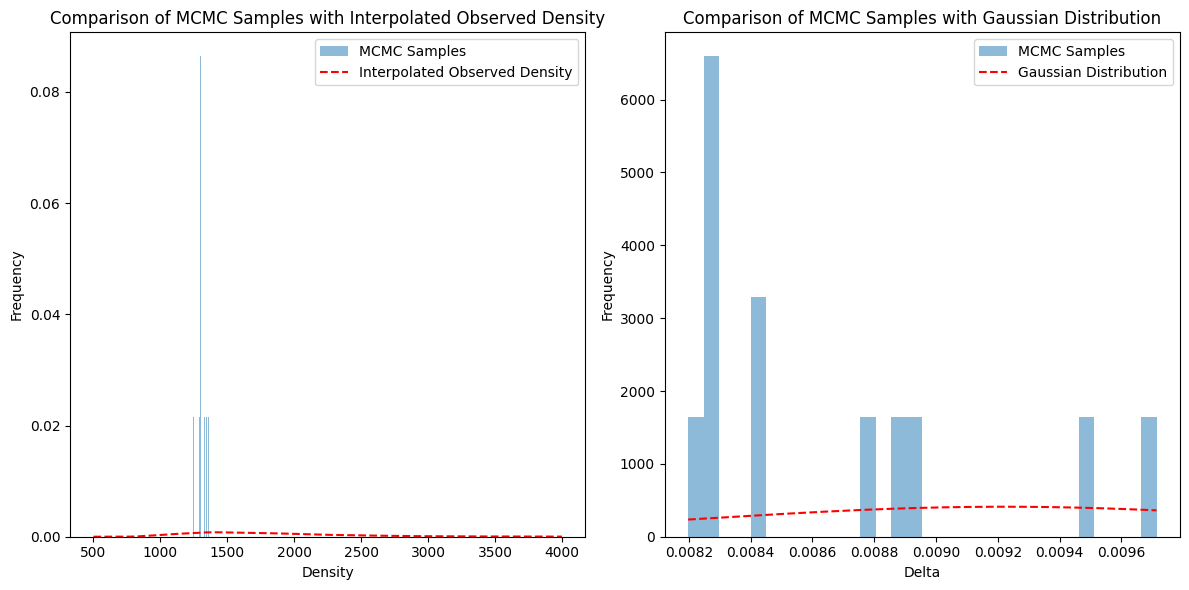

In [20]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# First subplot
axs[0].hist(Xs['rho_obs'], bins=30, density=True, alpha=0.5, label='MCMC Samples')
x = np.linspace(500, 4000, 400)
y = rho_obs_d_fun(x)
axs[0].plot(x, y, 'r--', label='Interpolated Observed Density')
axs[0].set_xlabel('Density')
axs[0].set_ylabel('Frequency')
axs[0].set_title('Comparison of MCMC Samples with Interpolated Observed Density')
axs[0].legend()

# Second subplot
axs[1].hist(Xs['delta'], bins=30, density=True, alpha=0.5, label='MCMC Samples')
delta_values = np.linspace(Xs['delta'].min(), Xs['delta'].max(), 400)
gaussian = (1/(delta_std * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((delta_values - delta_mean) / delta_std)**2)
axs[1].plot(delta_values, gaussian, 'r--', label='Gaussian Distribution')
axs[1].set_xlabel('Delta')
axs[1].set_ylabel('Frequency')
axs[1].set_title('Comparison of MCMC Samples with Gaussian Distribution')
axs[1].legend()

plt.tight_layout()
plt.show()

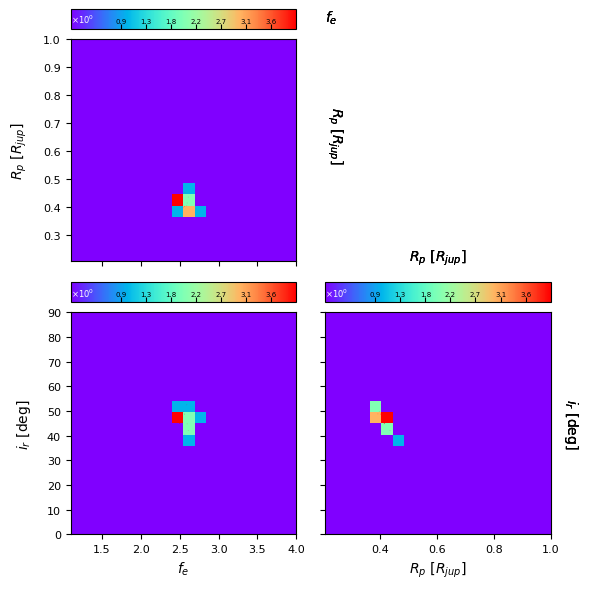

In [21]:
data = np.array(Xs[['fe', 'fRp', 'ir']])
properties=dict(
    fe=dict(label=r"$f_e$",range=fe_range),
    fRp=dict(label=r"$R_p$ [$R_{jup}$]",range=fRp_range),
    ir=dict(label=r"$i_r$ [deg]",range=ir_range),
)
G=PlotGrid(properties,figsize=3)

args=dict(alpha=1,bins=20,density=False,colorbar=1,cmap="rainbow")
hist=G.plotHist(data,**args)

args=dict(c='r',marker='.',s=2,edgecolors='none',alpha=0.2)
hist=G.scatterPlot(data,**args)


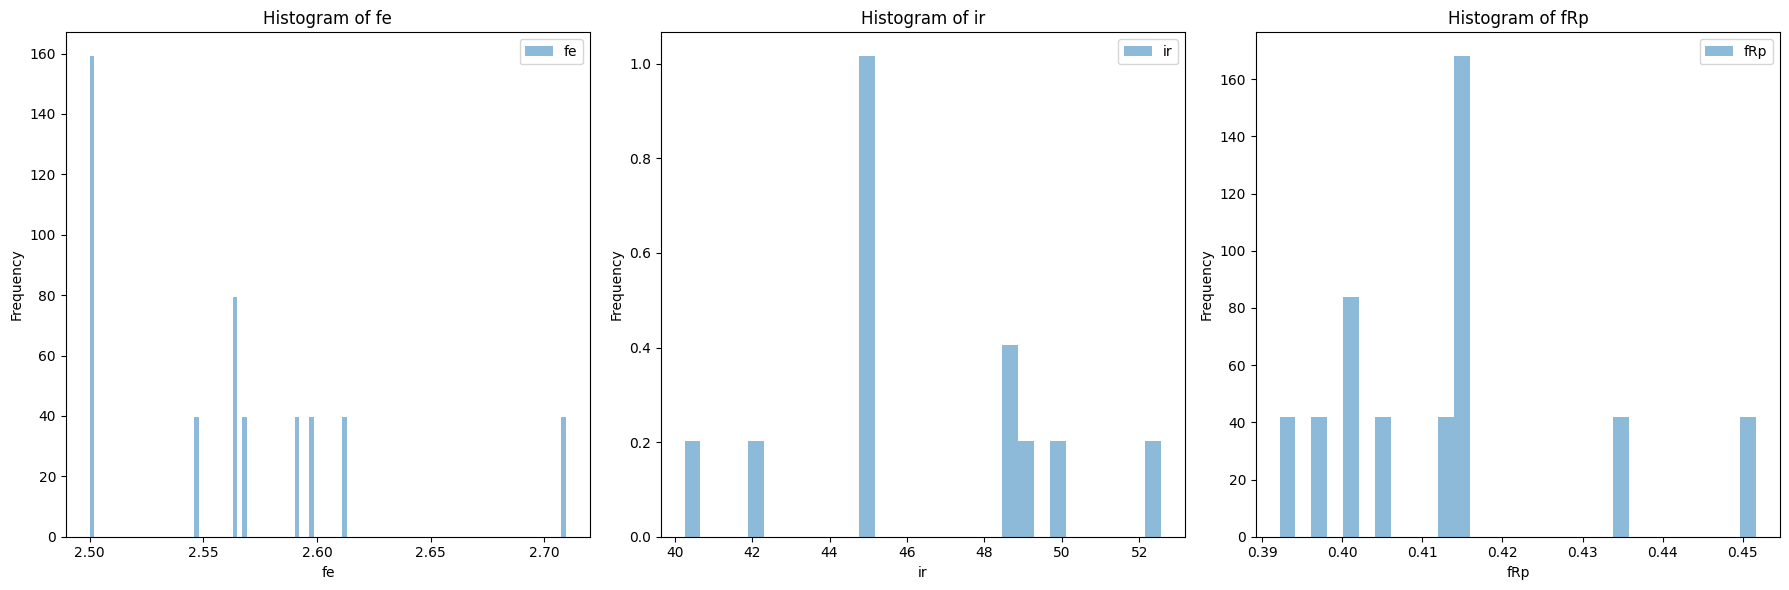

In [22]:
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

# First subplot
axs[0].hist(Xs['fe'], bins=100, density=True, alpha=0.5, label='fe')
axs[0].set_xlabel('fe')
axs[0].set_ylabel('Frequency')
axs[0].set_title('Histogram of fe')
axs[0].legend()

# Second subplot
axs[1].hist(Xs['ir'], bins=30, density=True, alpha=0.5, label='ir')
axs[1].set_xlabel('ir')
axs[1].set_ylabel('Frequency')
axs[1].set_title('Histogram of ir')
axs[1].legend()

# Third subplot
axs[2].hist(Xs['fRp'], bins=30, density=True, alpha=0.5, label='fRp')
axs[2].set_xlabel('fRp')
axs[2].set_ylabel('Frequency')
axs[2].set_title('Histogram of fRp')
axs[2].legend()

plt.tight_layout()
plt.show()

Let's generalize

In [23]:
eps = 0.1
props = dict(
    fe = dict(
        active=True,
        label=r"$f_e$",
        default=2.5,
        range=[1.1,4.0],
        eps=eps,
        scale=1,
    ),
    Rplanet = dict(
        active=True,
        label=r"$R_p$ [$R_{jup}$]",
        default=0.5*Rp_mean/RJUP,
        range=[fRp_min*Rp_mean/RJUP, Rp_mean/RJUP],
        eps=eps,
        scale=RJUP,
    ),
    ir = dict(
        active=True,
        label=r"$i_r$ [deg]",
        default=45.0,
        range=[0.0, 90.0],
        eps=eps,
        scale=DEG,
    ),
    phir = dict(
        active=0,
        label=r"$\phi_r$ [deg]",
        default=0.0,
        range=[0.0, 30.0],
        eps=eps,
        scale=DEG,
    ),
)
def activeProps(props):
    active = dict()
    for key,item in props.items():
        if item['active']:
            active[key] = item
    return active
props = activeProps(props)
props

{'fe': {'active': True,
  'label': '$f_e$',
  'default': 2.5,
  'range': [1.1, 4.0],
  'eps': 0.1,
  'scale': 1},
 'Rplanet': {'active': True,
  'label': '$R_p$ [$R_{jup}$]',
  'default': 0.4155,
  'range': [0.1715758081194531, 0.831],
  'eps': 0.1,
  'scale': 69911000.0},
 'ir': {'active': True,
  'label': '$i_r$ [deg]',
  'default': 45.0,
  'range': [0.0, 90.0],
  'eps': 0.1,
  'scale': 0.017453292519943295}}

In [24]:
# Seed 
np.random.seed(10)
verbose = 0

# Fixed values
Sd.tau = 1.0
Sd.phir = 0*DEG

# Number of iterations
Np = int(3e4)

# Arrays to store the values:
Xs = []

# Initial guess
pars = dict()
for prop,vals in props.items():
    pars[prop] = np.random.uniform(vals['range'][0], vals['range'][1]) * vals['scale']

# Initial guess
Sd.__dict__.update(pars)
msg = ""
for prop,vals in props.items():
    msg += f"{prop}: {getattr(Sd,prop)/vals['scale']}, "
if verbose:print(f"Guess parameters: {msg}")

# Update system
Sd.updateSystem()
Sd.calculate_PR()

# Store complimentary information
rho_obs = Sd.rho_obs
rho_true = Sd.rho_true
delta = Sd.Ar/np.pi
PR = Sd.PR
ieff = Sd.ieff*RAD
teff = Sd.teff*RAD

# Compute probability
p_rho_obs = float(rho_obs_d_fun(rho_obs))
p_delta = float(delta_fun(delta))

if verbose:print(f"\trho_obs: {rho_obs}, rho_true: {rho_true}, PR: {PR}, delta: {delta}")
if verbose:print(f"\tProbabilities: p_rho_obs: {p_rho_obs}, p_delta: {p_delta}")

for i in tqdm(range(Np)):

    if verbose:print(f"Step: {i}")

    # New parameters
    pars_new = dict()
    msg = ""
    for prop,vals in props.items():
        pars_new[prop] = pars[prop] + vals['eps']*(vals['range'][1] - vals['range'][0])*vals['scale'] * (2*np.random.rand() - 1)
        msg += f"{prop}: {pars_new[prop]/vals['scale']}, "

    if verbose:print(f"\tNew parameters (unbounded): fe: {msg}")

    # Check boundaries
    msg = ""
    for prop,vals in props.items():
        pars_new[prop] = (pars_new[prop] - vals['range'][0]*vals['scale']) % (vals['range'][1]*vals['scale'] - vals['range'][0]*vals['scale']) + vals['range'][0]*vals['scale']
        msg += f"{prop}: {pars_new[prop]/vals['scale']}, "


    # New guess
    Sd.__dict__.update(pars_new)
    msg = ""
    for prop,vals in props.items():
        msg += f"{prop}: {getattr(Sd,prop)/vals['scale']}, "
    if verbose:print(f"\tNew parameters (bounded): {msg}")
    
    # Calculate probabilities
    Sd.updateSystem()
    Sd.calculate_PR()

    # Store complimentary information
    rho_obsp = Sd.rho_obs
    rho_truep = Sd.rho_true
    deltap = Sd.Ar/np.pi
    PRp = Sd.PR
    ieffp = Sd.ieff*RAD
    teffp = Sd.teff*RAD

    p_rho_obs_p = float(rho_obs_d_fun(rho_obsp))
    p_delta_p = float(delta_fun(deltap))
    if verbose:print(f"\t\trho_obs: {rho_obsp}, rho_true: {rho_truep}, PR: {PRp}, delta: {deltap}")
    if verbose:print(f"\t\tProbabilities: p_rho_obs: {p_rho_obs_p}, p_delta: {p_delta_p}")
    
    # Acceptance ratio
    ratio = p_rho_obs_p/p_rho_obs * p_delta_p/p_delta
    alpha = mini(1,ratio)
    if verbose:print(f"\t\tRaw ratio: {ratio}")
    if verbose:print(f"\t\tAcceptance ratio: {alpha}")

    # Accept or reject
    if np.random.rand() < alpha:
        # Sample parameters
        pars = pars_new
        
        # Additional parameters
        rho_obs = rho_obsp
        rho_true = rho_truep
        delta = deltap
        PR = PRp
        ieff = ieffp
        teff = teffp
        p_rho_obs = p_rho_obs_p
        p_delta = p_delta_p

        if verbose:print("\t\tAccepted")
    else:
        if verbose:print("\t\tRejected")
    
    # Store the values
    values = [pars[prop]/vals['scale'] for prop,vals in props.items()]
    Xs.append(values + [rho_true, rho_obs, PR, ieff, teff, delta])
    
    #if i>10:break

columns = [prop for prop,vals in props.items()]
Xs = pd.DataFrame(Xs,columns=columns + ['rho_true', 'rho_obs', 'PR', 'ieff', 'teff', 'delta'])

100%|██████████| 30000/30000 [00:43<00:00, 691.52it/s]


Histogram target distributions:

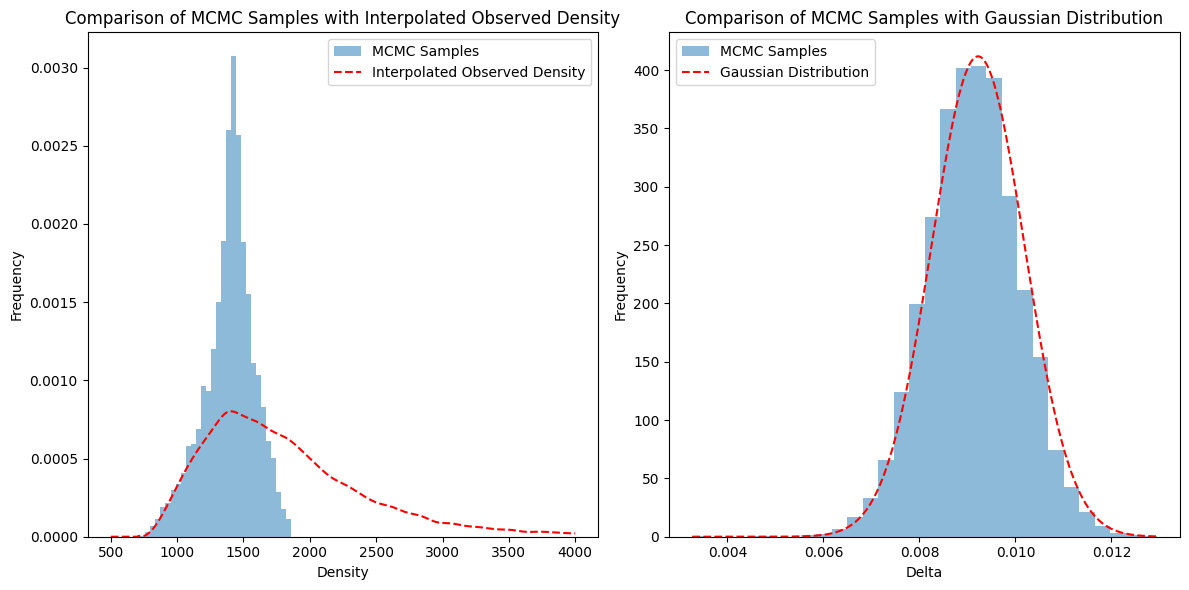

In [25]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# First subplot
axs[0].hist(Xs['rho_obs'], bins=30, density=True, alpha=0.5, label='MCMC Samples')
x = np.linspace(500, 4000, 400)
y = rho_obs_d_fun(x)
axs[0].plot(x, y, 'r--', label='Interpolated Observed Density')
axs[0].set_xlabel('Density')
axs[0].set_ylabel('Frequency')
axs[0].set_title('Comparison of MCMC Samples with Interpolated Observed Density')
axs[0].legend()

# Second subplot
axs[1].hist(Xs['delta'], bins=30, density=True, alpha=0.5, label='MCMC Samples')
delta_values = np.linspace(Xs['delta'].min(), Xs['delta'].max(), 400)
gaussian = (1/(delta_std * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((delta_values - delta_mean) / delta_std)**2)
axs[1].plot(delta_values, gaussian, 'r--', label='Gaussian Distribution')
axs[1].set_xlabel('Delta')
axs[1].set_ylabel('Frequency')
axs[1].set_title('Comparison of MCMC Samples with Gaussian Distribution')
axs[1].legend()

plt.tight_layout()
plt.show()

Corner plot

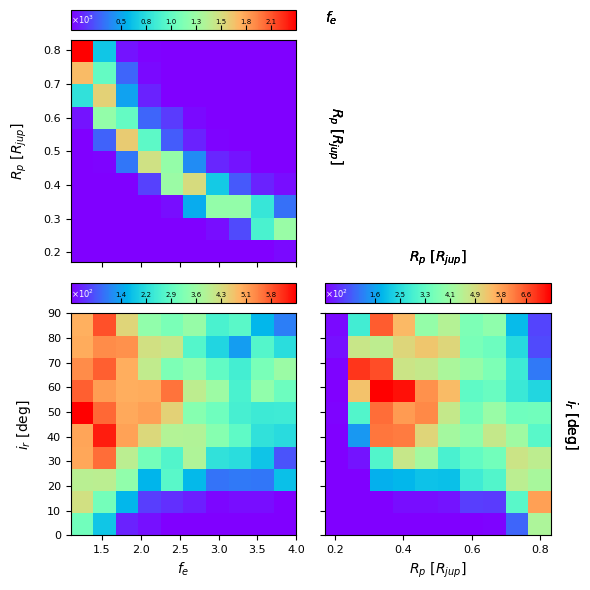

In [26]:
data = np.array(Xs[columns])
G=PlotGrid(props,figsize=3)

args=dict(alpha=1,bins=10,density=False,colorbar=1,cmap="rainbow")
hist=G.plotHist(data,**args)

args=dict(c='r',marker='.',s=2,edgecolors='none',alpha=0.2*0)
hist=G.scatterPlot(data,**args)


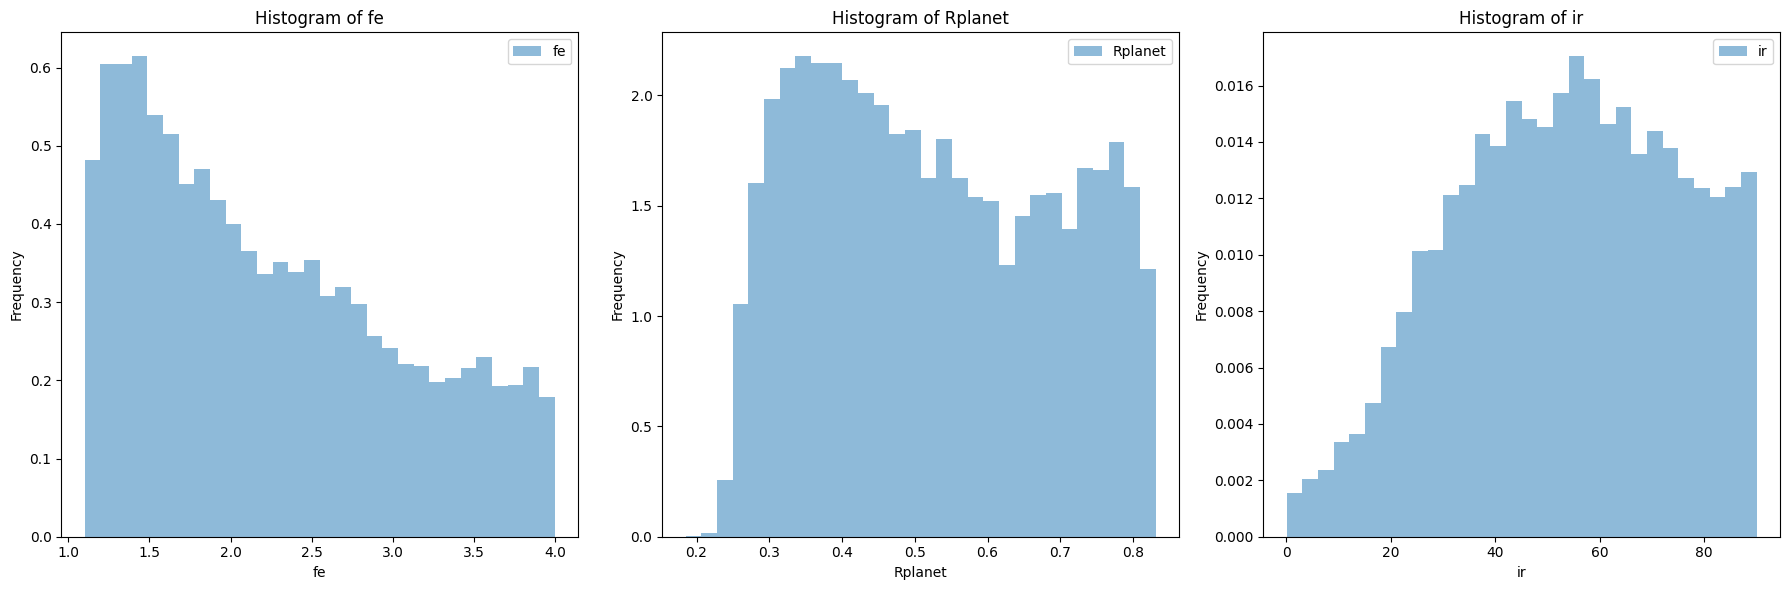

In [27]:
fig, axs = plt.subplots(1, len(props), figsize=(18, 6))

for i, (prop, vals) in enumerate(props.items()):
    axs[i].hist(Xs[prop], bins=30, density=True, alpha=0.5, label=prop)
    axs[i].set_xlabel(prop)
    axs[i].set_ylabel('Frequency')
    axs[i].set_title(f'Histogram of {prop}')
    axs[i].legend()

plt.tight_layout()
plt.show()

Automatize it:

In [28]:
def mcmc_walker(S,props,Np,seed=None,verbose=False,tqdm=lambda x:x):
 
    # Noauto 
    noauto = S.noauto
    S.noauto = True

    # Seed 
    if seed is not None:
        np.random.seed(seed)
    
    # Arrays to store the values:
    Xs = []

    # Initial guess
    pars = dict()
    for prop,vals in props.items():
        pars[prop] = np.random.uniform(vals['range'][0], vals['range'][1]) * vals['scale']

    # Initial guess
    S.__dict__.update(pars)
    msg = ""
    for prop,vals in props.items():
        msg += f"{prop}: {getattr(Sd,prop)/vals['scale']}, "
    if verbose:print(f"Guess parameters: {msg}")

    # Update system
    S.updateSystem()
    S.calculate_PR()

    # Store complimentary information
    rho_obs = S.rho_obs
    rho_true = S.rho_true
    delta = S.Ar/np.pi
    PR = S.PR
    ieff = S.ieff*RAD
    teff = S.teff*RAD

    # Compute probability
    p_rho_obs = float(rho_obs_d_fun(rho_obs))
    p_delta = float(delta_fun(delta))

    if verbose:print(f"\trho_obs: {rho_obs}, rho_true: {rho_true}, PR: {PR}, delta: {delta}")
    if verbose:print(f"\tProbabilities: p_rho_obs: {p_rho_obs}, p_delta: {p_delta}")

    for i in tqdm(range(Np)):

        if verbose:print(f"Step: {i}")

        # New parameters
        pars_new = dict()
        msg = ""
        for prop,vals in props.items():
            pars_new[prop] = pars[prop] + vals['eps']*(vals['range'][1] - vals['range'][0])*vals['scale'] * (2*np.random.rand() - 1)
            msg += f"{prop}: {pars_new[prop]/vals['scale']}, "

        if verbose:print(f"\tNew parameters (unbounded): fe: {msg}")

        # Check boundaries
        msg = ""
        for prop,vals in props.items():
            pars_new[prop] = (pars_new[prop] - vals['range'][0]*vals['scale']) % (vals['range'][1]*vals['scale'] - vals['range'][0]*vals['scale']) + vals['range'][0]*vals['scale']
            msg += f"{prop}: {pars_new[prop]/vals['scale']}, "


        # New guess
        S.__dict__.update(pars_new)
        msg = ""
        for prop,vals in props.items():
            msg += f"{prop}: {getattr(Sd,prop)/vals['scale']}, "
        if verbose:print(f"\tNew parameters (bounded): {msg}")
        
        # Calculate probabilities
        S.updateSystem()
        S.calculate_PR()

        # Store complimentary information
        rho_obsp = S.rho_obs
        rho_truep = S.rho_true
        deltap = S.Ar/np.pi
        PRp = S.PR
        ieffp = S.ieff*RAD
        teffp = S.teff*RAD

        p_rho_obs_p = float(rho_obs_d_fun(rho_obsp))
        p_delta_p = float(delta_fun(deltap))
        if verbose:print(f"\t\trho_obs: {rho_obsp}, rho_true: {rho_truep}, PR: {PRp}, delta: {deltap}")
        if verbose:print(f"\t\tProbabilities: p_rho_obs: {p_rho_obs_p}, p_delta: {p_delta_p}")
        
        # Acceptance ratio
        try:
            ratio = p_rho_obs_p/p_rho_obs * p_delta_p/p_delta
        except ZeroDivisionError:
            continue

        alpha = mini(1,ratio)
        if verbose:print(f"\t\tRaw ratio: {ratio}")
        if verbose:print(f"\t\tAcceptance ratio: {alpha}")

        # Accept or reject
        if np.random.rand() < alpha:
            # Sample parameters
            pars = pars_new
            
            # Additional parameters
            rho_obs = rho_obsp
            rho_true = rho_truep
            delta = deltap
            PR = PRp
            ieff = ieffp
            teff = teffp
            p_rho_obs = p_rho_obs_p
            p_delta = p_delta_p

            if verbose:print("\t\tAccepted")
        else:
            if verbose:print("\t\tRejected")
        
        # Store the values
        values = [pars[prop]/vals['scale'] for prop,vals in props.items()]
        Xs.append(values + [rho_true, rho_obs, PR, ieff, teff, delta])
        
    columns = [prop for prop,vals in props.items()]
    Xs = pd.DataFrame(Xs,columns=columns + ['rho_true', 'rho_obs', 'PR', 'ieff', 'teff', 'delta'])

    S.noauto = noauto
    return Xs

In [32]:
Sd.tau = 1.0
Sd.phir = 0.0*DEG
Sd.fi = 1.0
Xs = mcmc_walker(Sd,props,10000,seed=None,verbose=False,tqdm=tqdm)

100%|██████████| 10000/10000 [00:14<00:00, 697.92it/s]


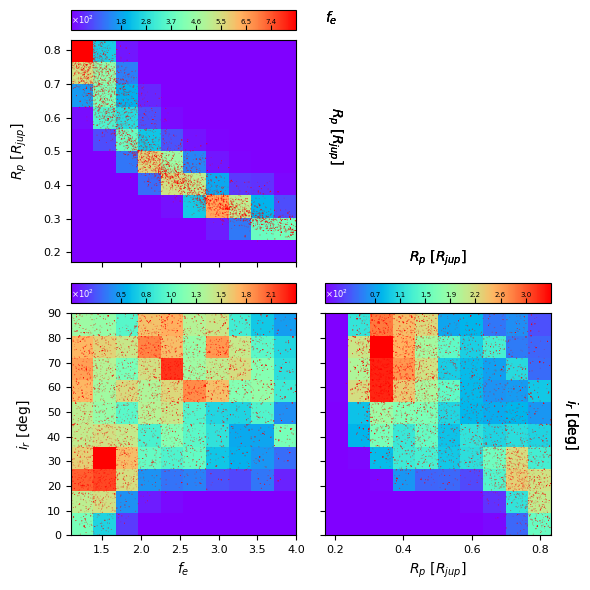

In [33]:
columns = [prop for prop,vals in props.items()]
data = np.array(Xs[columns])
G=PlotGrid(props,figsize=3)

args=dict(alpha=1,bins=10,density=False,colorbar=1,cmap="rainbow")
hist=G.plotHist(data,**args)

args=dict(c='r',marker='.',s=2,edgecolors='none',alpha=0.3)
hist=G.scatterPlot(data,**args)

In [38]:
import multiprocess as mp

# Define the number of parallel processes
num_processes = 4

# Define the number of iterations for each process
num_iterations = 100000 // num_processes

# Function to run the walker
def run_walker(seed):
    return mcmc_walker(Sd, props, num_iterations, seed=seed, verbose=False)

# Launch the walkers in parallel
with mp.Pool(processes=num_processes) as pool:
    results = pool.map(run_walker, range(num_processes))

# Combine the results
Xs = pd.concat(results, ignore_index=True)

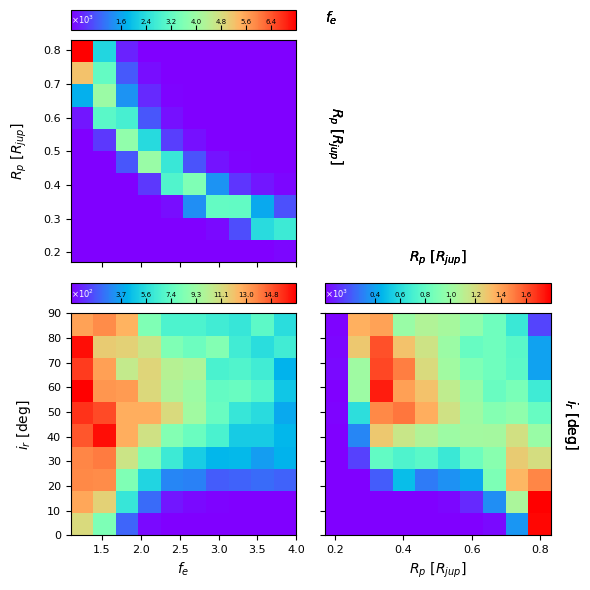

In [41]:
columns = [prop for prop,vals in props.items()]
data = np.array(Xs[columns])
G=PlotGrid(props,figsize=3)

args=dict(alpha=1,bins=10,density=False,colorbar=1,cmap="rainbow")
hist=G.plotHist(data,**args)

args=dict(c='r',marker='.',s=2,edgecolors='none',alpha=0)
hist=G.scatterPlot(data,**args)

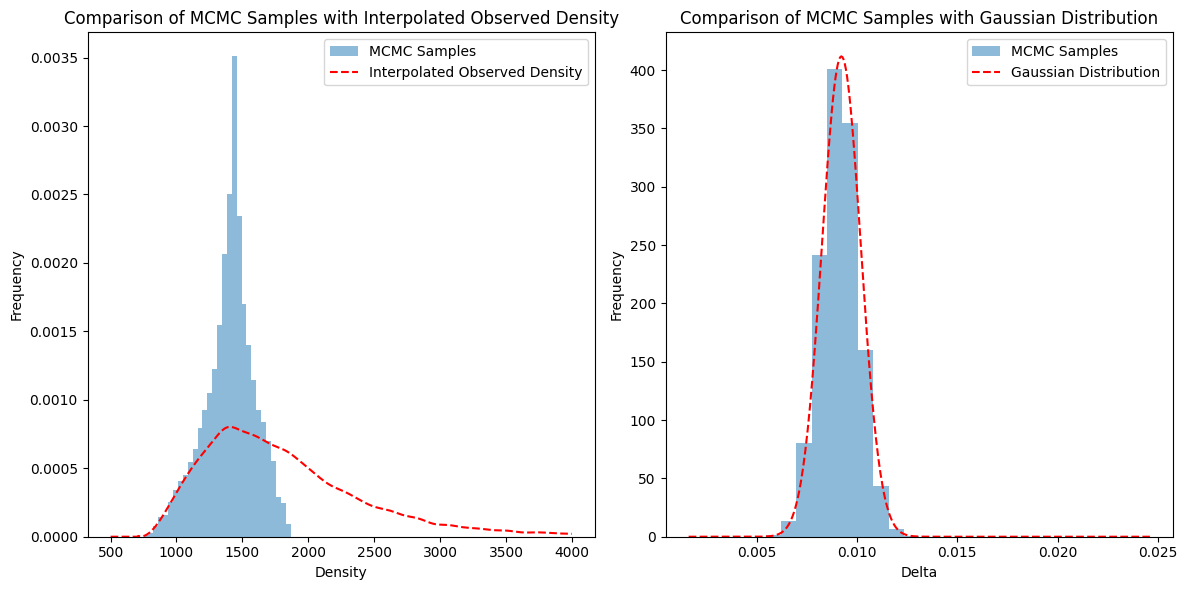

In [42]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# First subplot
axs[0].hist(Xs['rho_obs'], bins=30, density=True, alpha=0.5, label='MCMC Samples')
x = np.linspace(500, 4000, 400)
y = rho_obs_d_fun(x)
axs[0].plot(x, y, 'r--', label='Interpolated Observed Density')
axs[0].set_xlabel('Density')
axs[0].set_ylabel('Frequency')
axs[0].set_title('Comparison of MCMC Samples with Interpolated Observed Density')
axs[0].legend()

# Second subplot
axs[1].hist(Xs['delta'], bins=30, density=True, alpha=0.5, label='MCMC Samples')
delta_values = np.linspace(Xs['delta'].min(), Xs['delta'].max(), 400)
gaussian = (1/(delta_std * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((delta_values - delta_mean) / delta_std)**2)
axs[1].plot(delta_values, gaussian, 'r--', label='Gaussian Distribution')
axs[1].set_xlabel('Delta')
axs[1].set_ylabel('Frequency')
axs[1].set_title('Comparison of MCMC Samples with Gaussian Distribution')
axs[1].legend()

plt.tight_layout()
plt.show()

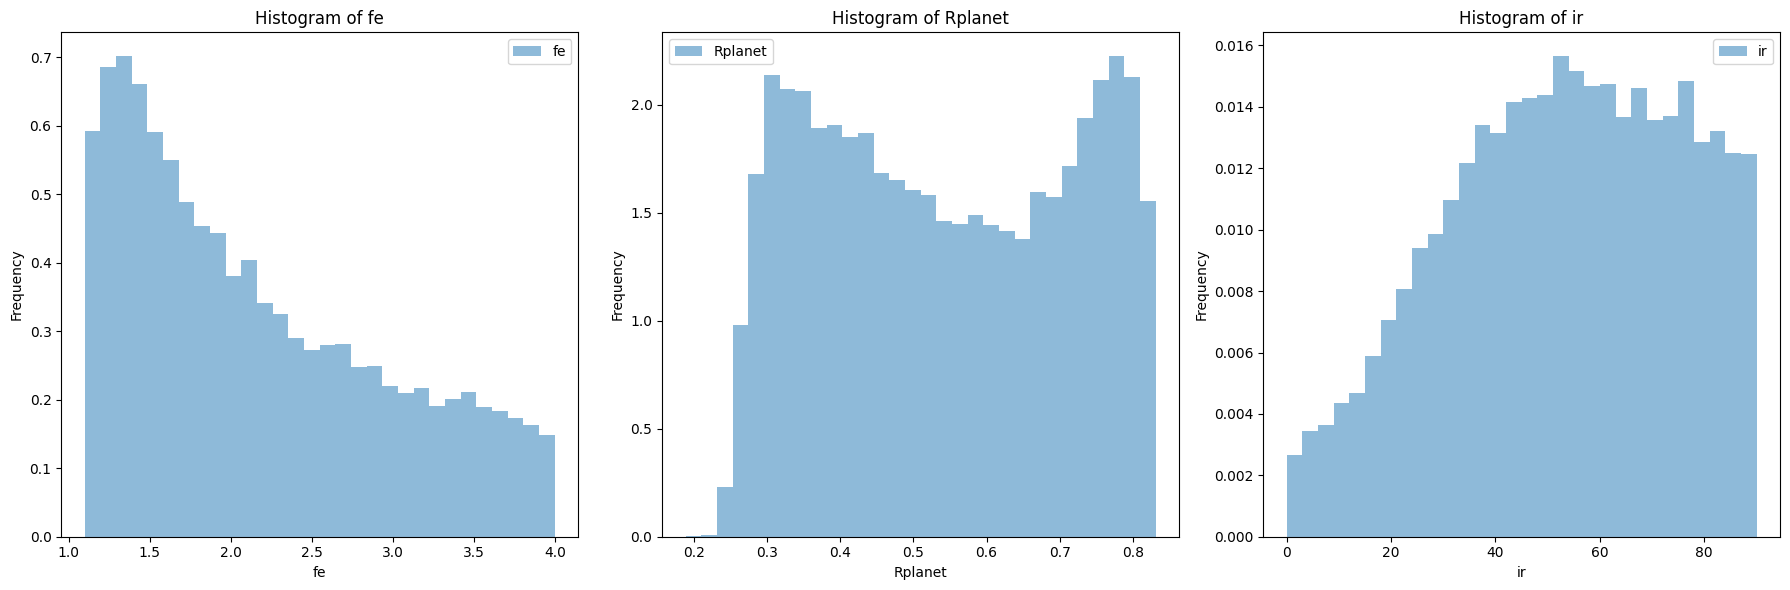

In [44]:
fig, axs = plt.subplots(1, len(props), figsize=(18, 6))

for i, (prop, vals) in enumerate(props.items()):
    axs[i].hist(Xs[prop], bins=30, density=True, alpha=0.5, label=prop)
    axs[i].set_xlabel(prop)
    axs[i].set_ylabel('Frequency')
    axs[i].set_title(f'Histogram of {prop}')
    axs[i].legend()

plt.tight_layout()
plt.show()

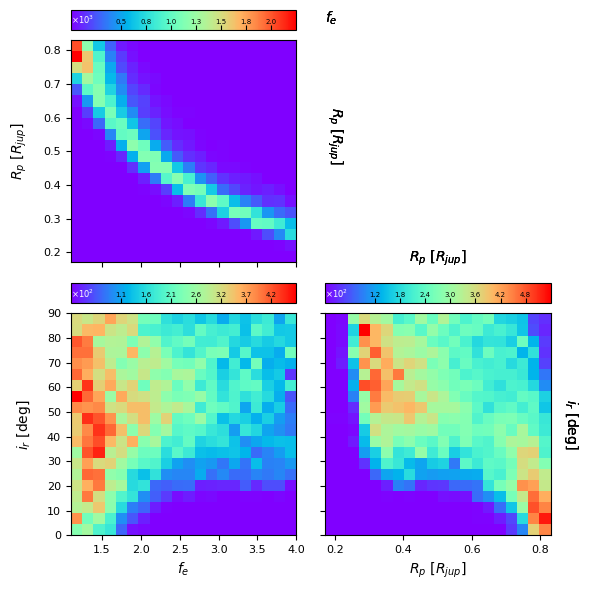

In [43]:
columns = [prop for prop,vals in props.items()]
data = np.array(Xs[columns])
G=PlotGrid(props,figsize=3)

args=dict(alpha=1,bins=20,density=False,colorbar=1,cmap="rainbow")
hist=G.plotHist(data,**args)

args=dict(c='r',marker='.',s=2,edgecolors='none',alpha=0.2*0)
hist=G.scatterPlot(data,**args)

### The effect of stellar uncertainty

Create the meshgrid of stellar masses

In [55]:
from scipy.stats import multivariate_normal

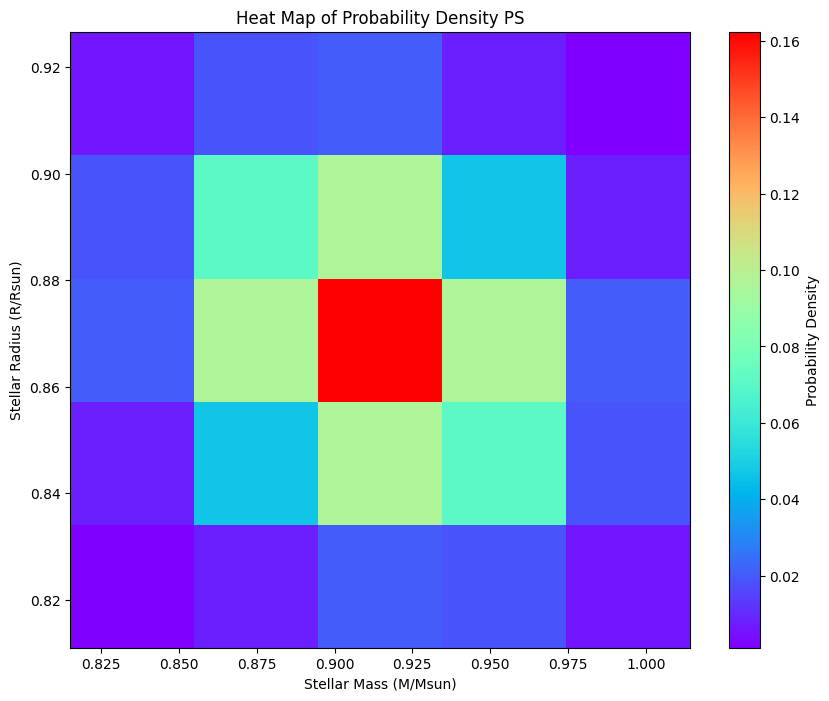

Minimum: 0.0010944907754310371, Maximum: 0.16243683359034986


In [87]:
Ns = int(1e4)

Ng = 5
ts = 2
MS, RS = np.meshgrid(
    np.linspace(Ms_mean - ts*Ms_std, Ms_mean + ts*Ms_std, Ng)/MSUN,
    np.linspace(Rs_mean - ts*Rs_std, Rs_mean + ts*Rs_std, Ng)/RSUN
)
delta_Ms = MS[0,1] - MS[0,0]
delta_Rs = RS[1,0] - RS[0,0]

mean = [M_mean, R_mean]
rho_MR = -0.2
cov = [
    [M_std**2, rho_MR * M_std * R_std], 
    [rho_MR * M_std * R_std, R_std**2]
]
PS = np.zeros(MS.shape)
for i in range(MS.shape[0]):
    for j in range(RS.shape[1]):
        PS[i, j] = multivariate_normal.pdf([MS[i, j], RS[i, j]], mean=mean, cov=cov)
PS = PS*delta_Ms*delta_Rs

plt.figure(figsize=(10, 8))
plt.imshow(PS, extent=[MS.min(), MS.max(), RS.min(), RS.max()], 
           origin='lower', aspect='auto', cmap='rainbow')
plt.colorbar(label='Probability Density')
plt.xlabel('Stellar Mass (M/Msun)')
plt.ylabel('Stellar Radius (R/Rsun)')
plt.title('Heat Map of Probability Density PS')
plt.show()

print(f"Minimum: {PS.min()}, Maximum: {PS.max()}")

In [107]:
eps = 0.1
props = dict(
    fe = dict(
        active=True,
        label=r"$f_e$",
        default=2.5,
        range=[1.1,4.0],
        eps=eps,
        scale=1,
    ),
    Rplanet = dict(
        active=True,
        label=r"$R_p$ [$R_{jup}$]",
        default=0.5*Rp_mean/RJUP,
        range=[fRp_min*Rp_mean/RJUP, Rp_mean/RJUP],
        eps=eps,
        scale=RJUP,
    ),
    ir = dict(
        active=True,
        label=r"$i_r$ [deg]",
        default=45.0,
        range=[0.0, 90.0],
        eps=eps,
        scale=DEG,
    ),
    phir = dict(
        active=1,
        label=r"$\phi_r$ [deg]",
        default=0.0,
        range=[0.0, 30.0],
        eps=eps,
        scale=DEG,
    ),
)
def activeProps(props):
    active = dict()
    for key,item in props.items():
        if item['active']:
            active[key] = item
    return active
props = activeProps(props)

In [131]:
def parallel_mcmc_walker(Sd, props, num_processes, Ns, verbose=False):
    
    # Define the number of iterations for each process
    num_iterations = Ns // num_processes

    # Function to run the walker
    def run_walker(seed):
        return mcmc_walker(Sd, props, num_iterations, seed=None, verbose=False)

    # Launch the walkers in parallel
    with mp.Pool(processes=num_processes) as pool:
        results = pool.map(run_walker, range(num_processes))

    # Combine the results
    Xs = pd.concat(results, ignore_index=True)

    return Xs

In [142]:
import time

# Name of the sample
sample_name = 'k51-planet_d-MR_simple_variance-N1e6'

# Total size of the sample
Ns = int(1e6)

# Number of processors
Nw = 4

# Prepare the data
columns = [prop for prop,vals in props.items()]
Xs = pd.DataFrame([],columns=columns + ['rho_true', 'rho_obs', 'PR', 'ieff', 'teff', 'delta'])

# Loop over the grid
Nsamples = 0
n = 0 
for i in range(MS.shape[0]):
    for j in range(RS.shape[1]):
        n += 1 

        # Update stellar parameters
        Sd.Mstar = MS[i, j]*MSUN
        Sd.Rstar = RS[i, j]*RSUN
        Sd.updateSystem()
        
        # Calculate the number of samples required
        Np = int(PS[i,j]*Ns)
        
        print(f"Stellar parameters {n}: M_star = {Mstar/MSUN}, R_star = {Rstar/RSUN}, Number of samples: {Np}")

        start_time = time.time()
        #results = mcmc_walker(Sd, props, Np, seed=None, verbose=False, tqdm=tqdm)
        results = parallel_mcmc_walker(Sd, props, Nw, Np, verbose=False)
        end_time = time.time()
        execution_time = end_time - start_time
        print(f"\tExecution time: {execution_time:.2f} seconds")

        Nsamples += len(results)

        # Accumulate
        Xs = pd.concat([Xs,results], ignore_index=True)
        
        # Save accumulated
        Xs.to_csv('tmp/ringed_sample-{sample_name}.csv', index=False)

Stellar parameters 1: M_star = 1.014265958336976, R_star = 0.9266591806104247, Number of samples: 1094
	Execution time: 0.46 seconds
Stellar parameters 2: M_star = 1.014265958336976, R_star = 0.9266591806104247, Number of samples: 7920
	Execution time: 3.12 seconds
Stellar parameters 3: M_star = 1.014265958336976, R_star = 0.9266591806104247, Number of samples: 20225
	Execution time: 7.06 seconds
Stellar parameters 4: M_star = 1.014265958336976, R_star = 0.9266591806104247, Number of samples: 18224
	Execution time: 8.07 seconds
Stellar parameters 5: M_star = 1.014265958336976, R_star = 0.9266591806104247, Number of samples: 5794
	Execution time: 2.37 seconds
Stellar parameters 6: M_star = 1.014265958336976, R_star = 0.9266591806104247, Number of samples: 7920
	Execution time: 2.99 seconds
Stellar parameters 7: M_star = 1.014265958336976, R_star = 0.9266591806104247, Number of samples: 46538
	Execution time: 22.00 seconds
Stellar parameters 8: M_star = 1.014265958336976, R_star = 0.9266

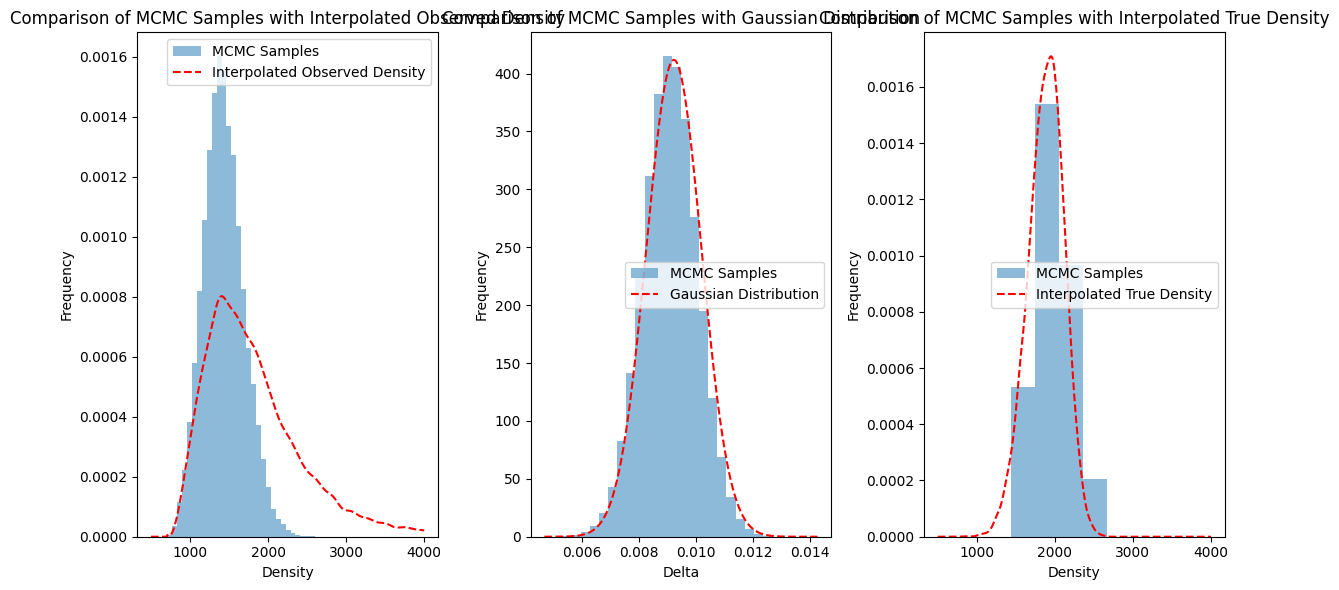

In [143]:
fig, axs = plt.subplots(1, 3, figsize=(12, 6))

# First subplot
axs[0].hist(Xs['rho_obs'], bins=30, density=True, alpha=0.5, label='MCMC Samples')
x = np.linspace(500, 4000, 400)
y = rho_obs_d_fun(x)
axs[0].plot(x, y, 'r--', label='Interpolated Observed Density')
axs[0].set_xlabel('Density')
axs[0].set_ylabel('Frequency')
axs[0].set_title('Comparison of MCMC Samples with Interpolated Observed Density')
axs[0].legend()

# Second subplot
axs[1].hist(Xs['delta'], bins=30, density=True, alpha=0.5, label='MCMC Samples')
delta_values = np.linspace(Xs['delta'].min(), Xs['delta'].max(), 400)
gaussian = (1/(delta_std * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((delta_values - delta_mean) / delta_std)**2)
axs[1].plot(delta_values, gaussian, 'r--', label='Gaussian Distribution')
axs[1].set_xlabel('Delta')
axs[1].set_ylabel('Frequency')
axs[1].set_title('Comparison of MCMC Samples with Gaussian Distribution')
axs[1].legend()

# Third subplot
axs[2].hist(Xs['rho_true'], bins=4, density=True, alpha=0.5, label='MCMC Samples')
x = np.linspace(500, 4000, 400)
y = rho_true_fun(x)
axs[2].plot(x, y, 'r--', label='Interpolated True Density')
axs[2].set_xlabel('Density')
axs[2].set_ylabel('Frequency')
axs[2].set_title('Comparison of MCMC Samples with Interpolated True Density')
axs[2].legend()

plt.tight_layout()
plt.show()

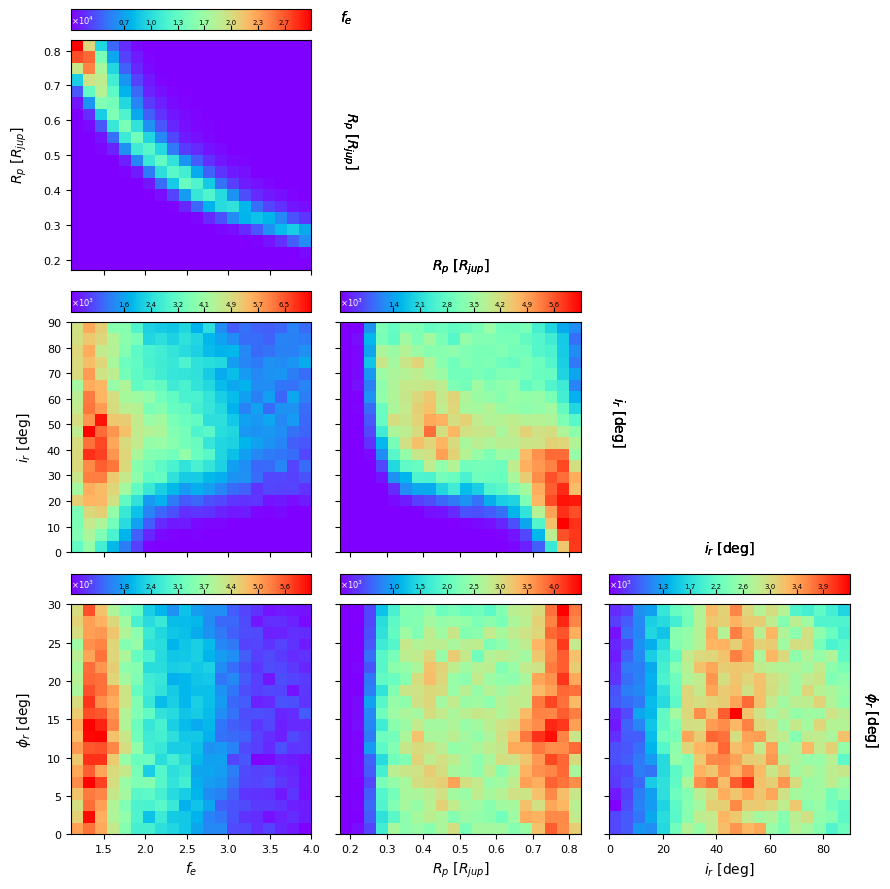

In [144]:
columns = [prop for prop,vals in props.items()]
data = np.array(Xs[columns])
G=PlotGrid(props,figsize=3)

args=dict(alpha=1,bins=20,density=False,colorbar=1,cmap="rainbow")
hist=G.plotHist(data,**args)

args=dict(c='r',marker='.',s=2,edgecolors='none',alpha=0.2*0)
hist=G.scatterPlot(data,**args)

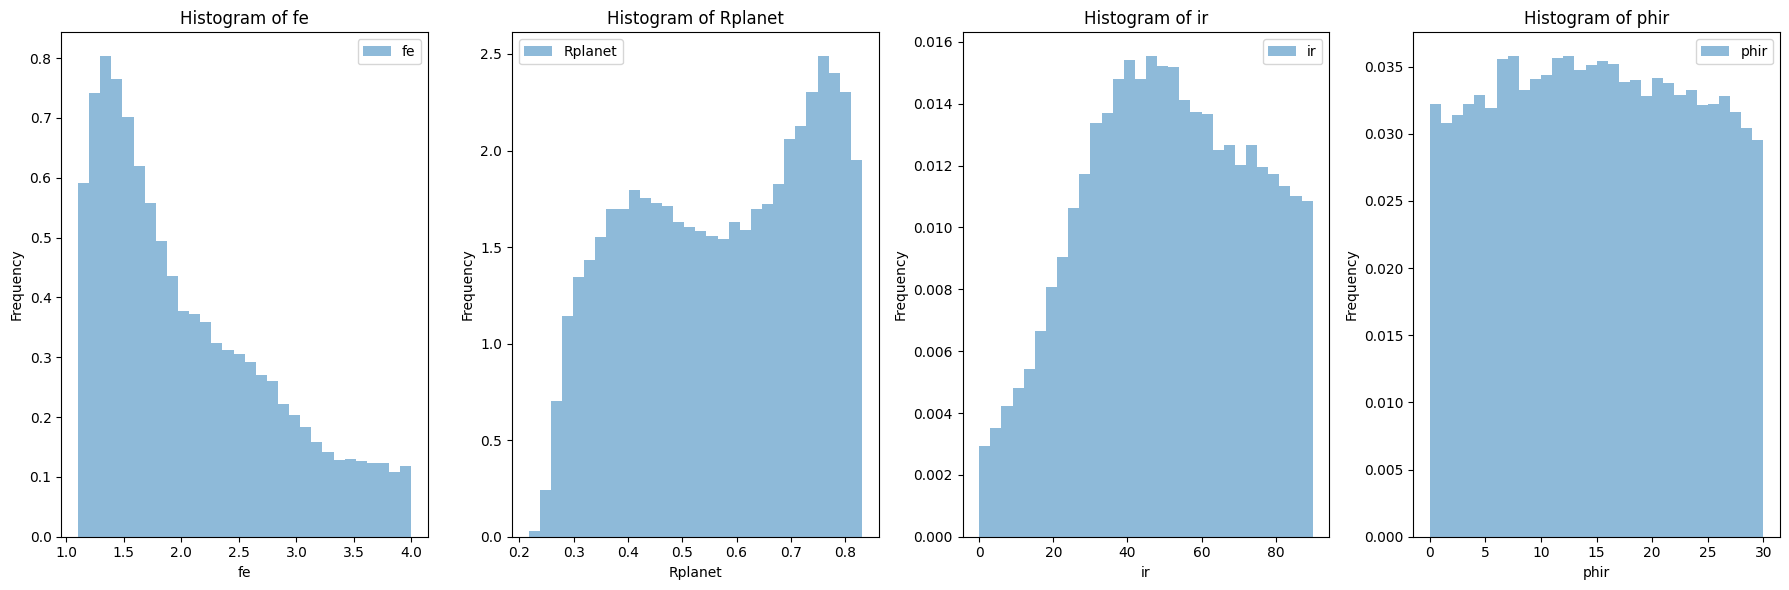

In [145]:
fig, axs = plt.subplots(1, len(props), figsize=(18, 6))

for i, (prop, vals) in enumerate(props.items()):
    axs[i].hist(Xs[prop], bins=30, density=True, alpha=0.5, label=prop)
    axs[i].set_xlabel(prop)
    axs[i].set_ylabel('Frequency')
    axs[i].set_title(f'Histogram of {prop}')
    axs[i].legend()

plt.tight_layout()
plt.show()

Parallel walker:

In [ ]:
import multiprocess as mp

In [ ]:
%timeit -n 1 -r 1 Xs = parallel_mcmc_walker(Sd, props, 4, int(1e4), verbose=False)

3.76 s ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


In [130]:
%timeit -n 1 -r 1 Xs = mcmc_walker(Sd, props, int(1e4), verbose=False)

13 s ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)
